# Setup

In [1]:
# === All imports for this notebook ===
import time
import os
import pickle
import warnings
import joblib

warnings.filterwarnings("ignore")

# Dataframes & stats
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# ML: scikit-learn
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ML: TabPFN
from tabpfn import TabPFNClassifier

# ML: Torch
import torch

# Surrogate-model candidates (used by §8.0 surrogate exploration)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Explainability
import shap
import dice_ml

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff
import plotly.express as px
import plotly.io as pio

print("Core libraries loaded.")


Core libraries loaded.


In [2]:
# Setting up the GPU
if torch.cuda.is_available():
    device = "cuda"
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    device = "cpu"
    print("Using CPU.")

GPU: NVIDIA GeForce RTX 3060 Ti


In [3]:
# Constants
random_state = 8 # Lucky Number
years = ["2020", "2021", "2022", "2024"]

features_const = ["ID", "SEX"]
features = ["AGE", "MARRIED", "CHILD", "HINCOME_group", "JOB_group",
            "Exercise", "HealthyDiet", "Activity", "Interaction_offline",
            "Interaction_online", "Altruistic", "Optimism", "HealthySleep",
            "DeteriorationEconomy", "DeteriorationInteract", "Frustration",
            "CovidAnxiety", "CovidSleepless", "Difficultyliving", "DifficultyWork"]
target = "UCLA"

features_UCLA = ["Sex_Male", "Age", "Is_Married", "Has_Child", "Income", "Income_Missing",
                 "Job_Employed", "Job_Homemaker", "Job_Student", "Job_Unemployed", "Job_Other",
                 "Activity", "Exercise", "Healthy_Diet", "Healthy_Sleep",
                 "Interaction_Offline", "Interaction_Online",
                 "Altruistic", "Frustration", "Optimism",
                 "Covid_Anxiety", "Covid_Sleepless", "Deterioration_Economy", "Deterioration_Interact",
                 "Difficulty_Living", "Difficulty_Work"]
target_UCLA = "UCLA_High"
vars_UCLA = ["ID", "Phase", "Year"]
UCLA_cutoff = 22

print("Constants loaded.")

Constants loaded.


In [4]:
# =====================================================================
# NOTEBOOK RUN CONFIG
# =====================================================================

# Set True to skip model training and load saved TabPFN from disk.
LOAD_SAVED_MODEL = True

# Set True to load previously saved counterfactuals instead of regenerating.
LOAD_SAVED_CF = True

# Number of test samples to generate counterfactuals for.
N_CF_SAMPLES = 60

# Number of counterfactual examples per sample.
N_CF_PER_SAMPLE = 5

# Batch size for GPU safety
SHAP_BATCH_SIZE = 128

print("XAI runtime configurations loaded.")

XAI runtime configurations loaded.


In [5]:
# Utilities
def format_time(seconds):
    hrs = int(seconds // 3600)
    mins = int((seconds % 3600) // 60)
    secs = seconds % 60
    parts = []
    if hrs: parts.append(f"{hrs}h")
    if mins: parts.append(f"{mins}m")
    parts.append(f"{secs:.2f}s")
    return " ".join(parts)

print("Utilities loaded.")

Utilities loaded.


In [6]:
CATEGORY_LABELS = {
    "Sex_Male": {0: "Female", 1: "Male"},
    "Is_Married": {0: "Unmarried", 1: "Married"},
    "Has_Child": {0: "No Children", 1: "Has Children"},
    "Income": {
        0: "Missing",
        1: "<2.0M JPY",
        2: "2.0-3.9M JPY",
        3: "4.0-5.9M JPY",
        4: "6.0-7.9M JPY",
        5: ">=8.0M JPY"
    },
    "Income_Missing": {0: "Income Reported", 1: "Income Missing"},
    "Job_Employed": {0: "Not Employed", 1: "Employed"},
    "Job_Homemaker": {0: "Not Homemaker", 1: "Homemaker"},
    "Job_Student": {0: "Not Student", 1: "Student"},
    "Job_Unemployed": {0: "Not Unemployed", 1: "Unemployed"},
    "Job_Other": {0: "Not Other Job", 1: "Other Job"},
}

FEATURE_DISPLAY_NAMES = {
    "Sex_Male": "Sex",
    "Age": "Age",
    "Is_Married": "Marital Status",
    "Has_Child": "Has Children",
    "Income": "Household Income",
    "Income_Missing": "Income Missing",
    "Job_Employed": "Employed",
    "Job_Homemaker": "Homemaker",
    "Job_Student": "Student",
    "Job_Unemployed": "Unemployed",
    "Job_Other": "Other Job",
    "Activity": "Social/Physical Activity",
    "Exercise": "Exercise Frequency",
    "Healthy_Diet": "Healthy Diet",
    "Healthy_Sleep": "Healthy Sleep",
    "Interaction_Offline": "Offline Social Interaction",
    "Interaction_Online": "Online Social Interaction",
    "Altruistic": "Altruistic Behavior",
    "Frustration": "Frustration Level",
    "Optimism": "Optimism Level",
    "Covid_Anxiety": "COVID Anxiety",
    "Covid_Sleepless": "COVID-related Sleeplessness",
    "Deterioration_Economy": "Economic Deterioration",
    "Deterioration_Interact": "Social Interaction Deterioration",
    "Difficulty_Living": "Difficulty Living",
    "Difficulty_Work": "Difficulty Working",
}

# Continuous feature scale description (1-7 Likert scale)
LIKERT_FEATURES = [
    "Activity", "Exercise", "Healthy_Diet", "Healthy_Sleep",
    "Interaction_Offline", "Interaction_Online",
    "Altruistic", "Frustration", "Optimism",
    "Covid_Anxiety", "Covid_Sleepless", "Deterioration_Economy",
    "Deterioration_Interact", "Difficulty_Living", "Difficulty_Work"
]

def get_display_name(feat):
    """Get human-readable display name for a feature."""
    return FEATURE_DISPLAY_NAMES.get(feat, feat)

def get_display_names_list(feat_list):
    """Get list of human-readable display names."""
    return [get_display_name(f) for f in feat_list]

def format_feature_value(feat, value):
    """Format a feature value with its category label if applicable."""
    if feat in CATEGORY_LABELS:
        int_val = int(round(value))
        label = CATEGORY_LABELS[feat].get(int_val, str(int_val))
        return f"{label}"
    elif feat in LIKERT_FEATURES:
        return f"{value:.1f}/7"
    elif feat == "Age":
        return f"{value:.0f} years"
    else:
        return f"{value:.2f}"

print("Category mappings loaded.")

Category mappings loaded.


In [7]:
# Output directories
os.makedirs("plots/shap", exist_ok=True)
os.makedirs("plots/counterfactuals", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("explainers", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

print("Output directories created.")

Output directories created.


# Dataset Loading & Preprocessing

In [8]:
DATA_PATH = "../../data/dataset.csv"

df = pd.read_csv(DATA_PATH, na_values=["NA", "N/A", "NaN", "null", "NULL", "", " ", "-"])
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 2659 rows, 106 columns


,ID,SEX,AGE_1,MARRIED_1,CHILD_1,HINCOME_group_1,JOB_group_1,LSNS_group_1,K6_1,PHQ9_1,...,Altruistic_4,Optimism_4,HealthySleep_4,DeteriorationEconomy_4,DeteriorationInteract_4,Frustration_4,CovidAnxiety_4,CovidSleepless_4,Difficultyliving_4,DifficultyWork_4
0,1,1,53,2,2,4.0,1,1,3,8,...,5,4,4,4,3,3,5,5,5,5
1,2,2,66,2,2,5.0,2,0,1,0,...,7,7,7,1,1,1,5,1,1,6
2,3,1,48,1,1,3.0,1,1,3,6,...,1,3,5,4,1,1,1,1,1,1
3,4,1,62,2,2,5.0,1,1,0,0,...,1,5,5,1,1,1,1,1,1,1
4,5,1,59,2,2,5.0,1,0,1,6,...,2,5,5,4,4,4,4,2,4,4


In [9]:
# Reshape longitudinal data
df_prep_list = []
for i, year in enumerate(years, 1):
    current_features = [f"{col}_{i}" for col in features]
    current_target = [f"{col}_{i}" for col in [target]]
    cols_to_select = features_const + current_features + current_target
    temp_df = df[cols_to_select].copy()
    rename_mapping = {f"{col}_{i}": col for col in features + [target]}
    temp_df = temp_df.rename(columns=rename_mapping)
    temp_df["Phase"] = i
    temp_df["Year"] = year
    df_prep_list.append(temp_df)

df_prep = pd.concat(df_prep_list, ignore_index=True)
print(f"Reshaped: {df_prep.shape}")

Reshaped: (10636, 25)


In [10]:
# Handle missing data
missing_values = df_prep.isnull().sum()
missing_percent = 100 * df_prep.isnull().sum() / len(df_prep)
missing_df = pd.DataFrame({"Missing Count": missing_values, "Missing Percentage": missing_percent})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(by="Missing Count", ascending=False)
if missing_df.empty:
    print("No missing values.")
else:
    display(missing_df)

,Missing Count,Missing Percentage
HINCOME_group,1860,17.487777


In [11]:
# Encode categorical features
df_encoded = df_prep.copy()
df_encoded["Sex_Male"] = (df_encoded["SEX"] == 1).astype(int)
df_encoded["Is_Married"] = (df_encoded["MARRIED"] == 2).astype(int)
df_encoded["Has_Child"] = (df_encoded["CHILD"] == 2).astype(int)
df_encoded["Income_Missing"] = df_encoded["HINCOME_group"].isna().astype(int)
df_encoded["Income"] = df_encoded["HINCOME_group"].fillna(0).astype(int)

job_map = {1: "Job_Employed", 2: "Job_Homemaker", 3: "Job_Student",
           4: "Job_Unemployed", 5: "Job_Other"}
job_labels = df_encoded["JOB_group"].astype("Int64").map(job_map)
job_encoding = pd.get_dummies(job_labels, dtype=int)
df_encoded = pd.concat([df_encoded, job_encoding], axis=1)

df_encoded = df_encoded.rename(columns={
    "AGE": "Age", "HealthyDiet": "Healthy_Diet", "HealthySleep": "Healthy_Sleep",
    "Interaction_offline": "Interaction_Offline", "Interaction_online": "Interaction_Online",
    "CovidAnxiety": "Covid_Anxiety", "CovidSleepless": "Covid_Sleepless",
    "DeteriorationEconomy": "Deterioration_Economy",
    "DeteriorationInteract": "Deterioration_Interact",
    "Difficultyliving": "Difficulty_Living", "DifficultyWork": "Difficulty_Work"
})

df_encoded[target_UCLA] = (df_encoded["UCLA"] >= UCLA_cutoff).astype(int)
df_encoded = df_encoded.drop(columns=["SEX", "MARRIED", "CHILD", "HINCOME_group", "JOB_group", "UCLA"])
df_encoded = df_encoded[vars_UCLA + features_UCLA + [target_UCLA]]
print(f"Encoded: {df_encoded.shape}")
print(f"Target distribution:\n{df_encoded[target_UCLA].value_counts()}")

Encoded: (10636, 30)
Target distribution:
UCLA_High
1    7128
0    3508
Name: count, dtype: int64


# EDA

In [12]:
# Statistical
df_encoded.describe()

,ID,Phase,Sex_Male,Age,Is_Married,Has_Child,Income,Income_Missing,Job_Employed,Job_Homemaker,...,Altruistic,Frustration,Optimism,Covid_Anxiety,Covid_Sleepless,Deterioration_Economy,Deterioration_Interact,Difficulty_Living,Difficulty_Work,UCLA_High
count,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,...,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000
mean,1330.000000,2.500000,0.582926,53.791087,0.644321,0.570985,2.720666,0.174878,0.687759,0.139150,...,5.087909,3.031685,4.112354,3.291087,2.356149,3.493983,2.537890,2.646296,2.796822,0.670177
std,767.623216,1.118087,0.493099,12.784209,0.478741,0.494959,1.737744,0.379880,0.463430,0.346119,...,1.843496,1.683804,1.550914,1.686384,1.472101,1.702638,1.523418,1.641990,1.751135,0.470171
min,1.000000,1.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,665.000000,1.750000,0.000000,45.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,4.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000
50%,1330.000000,2.500000,1.000000,54.000000,1.000000,1.000000,3.000000,0.000000,1.000000,0.000000,...,5.000000,3.000000,4.000000,4.000000,2.000000,4.000000,2.000000,2.000000,3.000000,1.000000
75%,1995.000000,3.250000,1.000000,63.000000,1.000000,1.000000,4.000000,0.000000,1.000000,0.000000,...,7.000000,4.000000,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,1.000000
max,2659.000000,4.000000,1.000000,92.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,1.000000


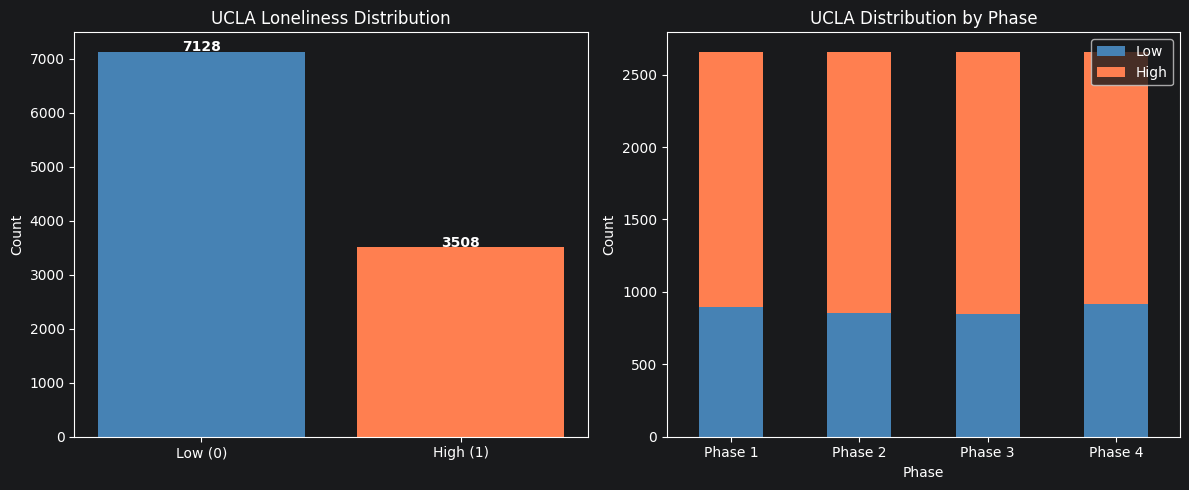

Saved: plots/target_distribution.png


In [13]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df_encoded[target_UCLA].value_counts()
axes[0].bar(["Low (0)", "High (1)"], counts.values, color=["steelblue", "coral"])
axes[0].set_title("UCLA Loneliness Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

phase_target = df_encoded.groupby("Phase")[target_UCLA].value_counts().unstack(fill_value=0)
phase_target.plot(kind="bar", stacked=True, ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("UCLA Distribution by Phase")
axes[1].set_ylabel("Count")
axes[1].legend(["Low", "High"])
axes[1].set_xticklabels([f"Phase {i}" for i in range(1, 5)], rotation=0)

plt.tight_layout()
plt.savefig("plots/target_distribution.png", dpi=150, bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print("Saved: plots/target_distribution.png")

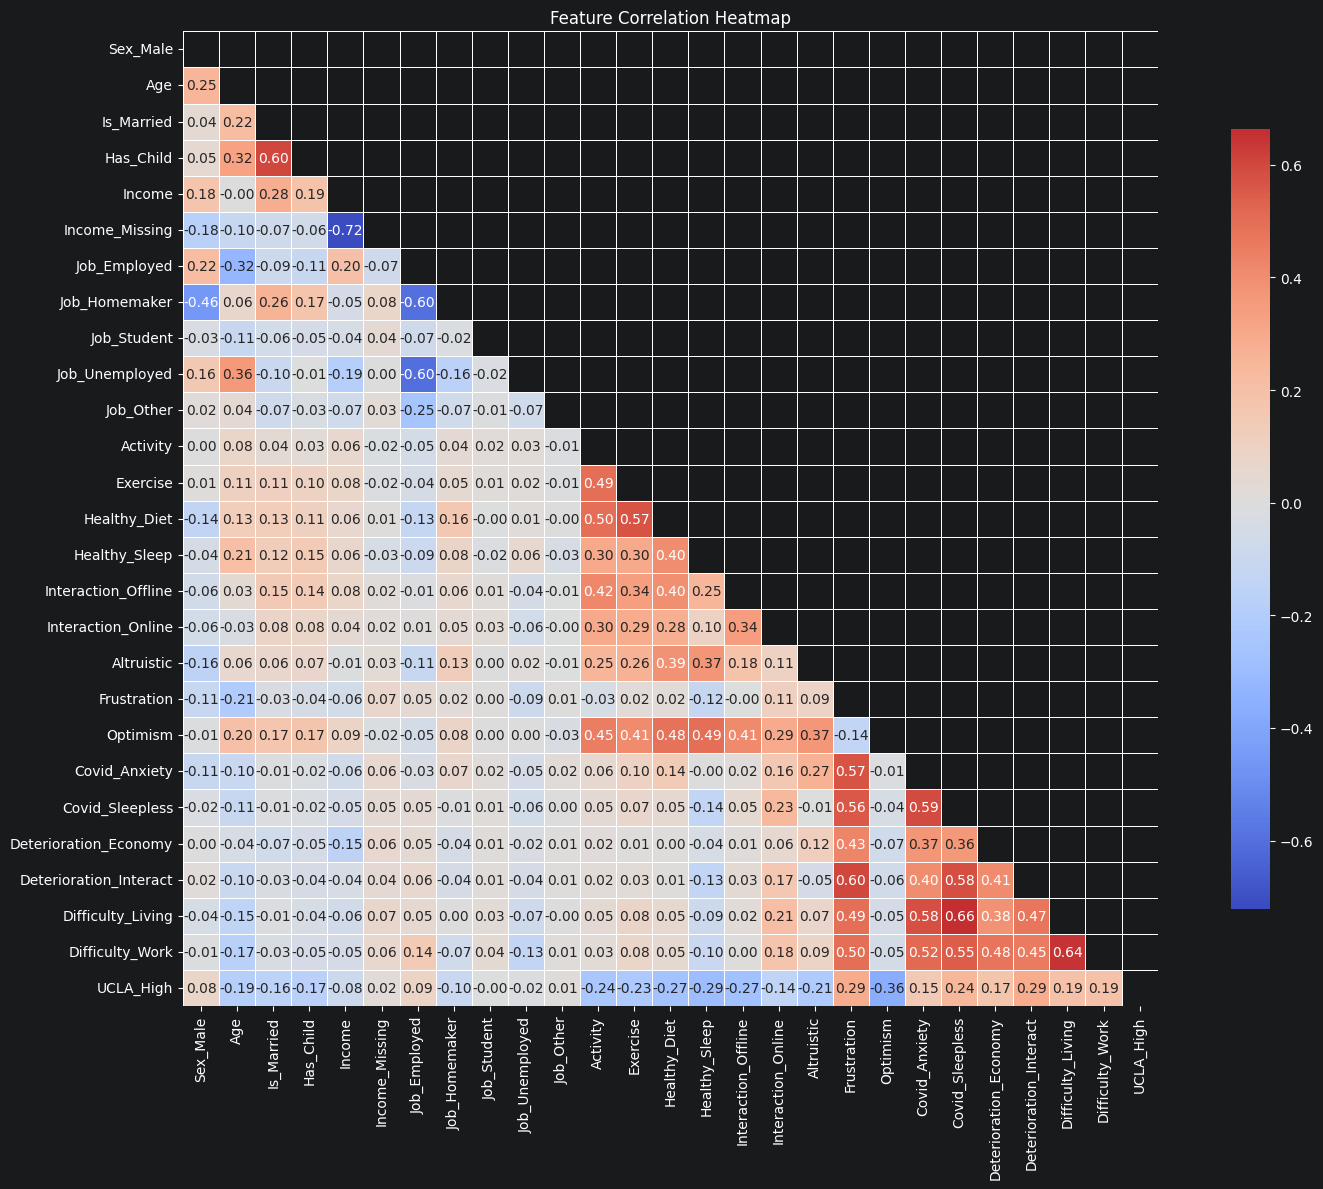

Saved: plots/correlation_heatmap.png


In [14]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
corr = df_encoded[features_UCLA + [target_UCLA]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", dpi=150, bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print("Saved: plots/correlation_heatmap.png")

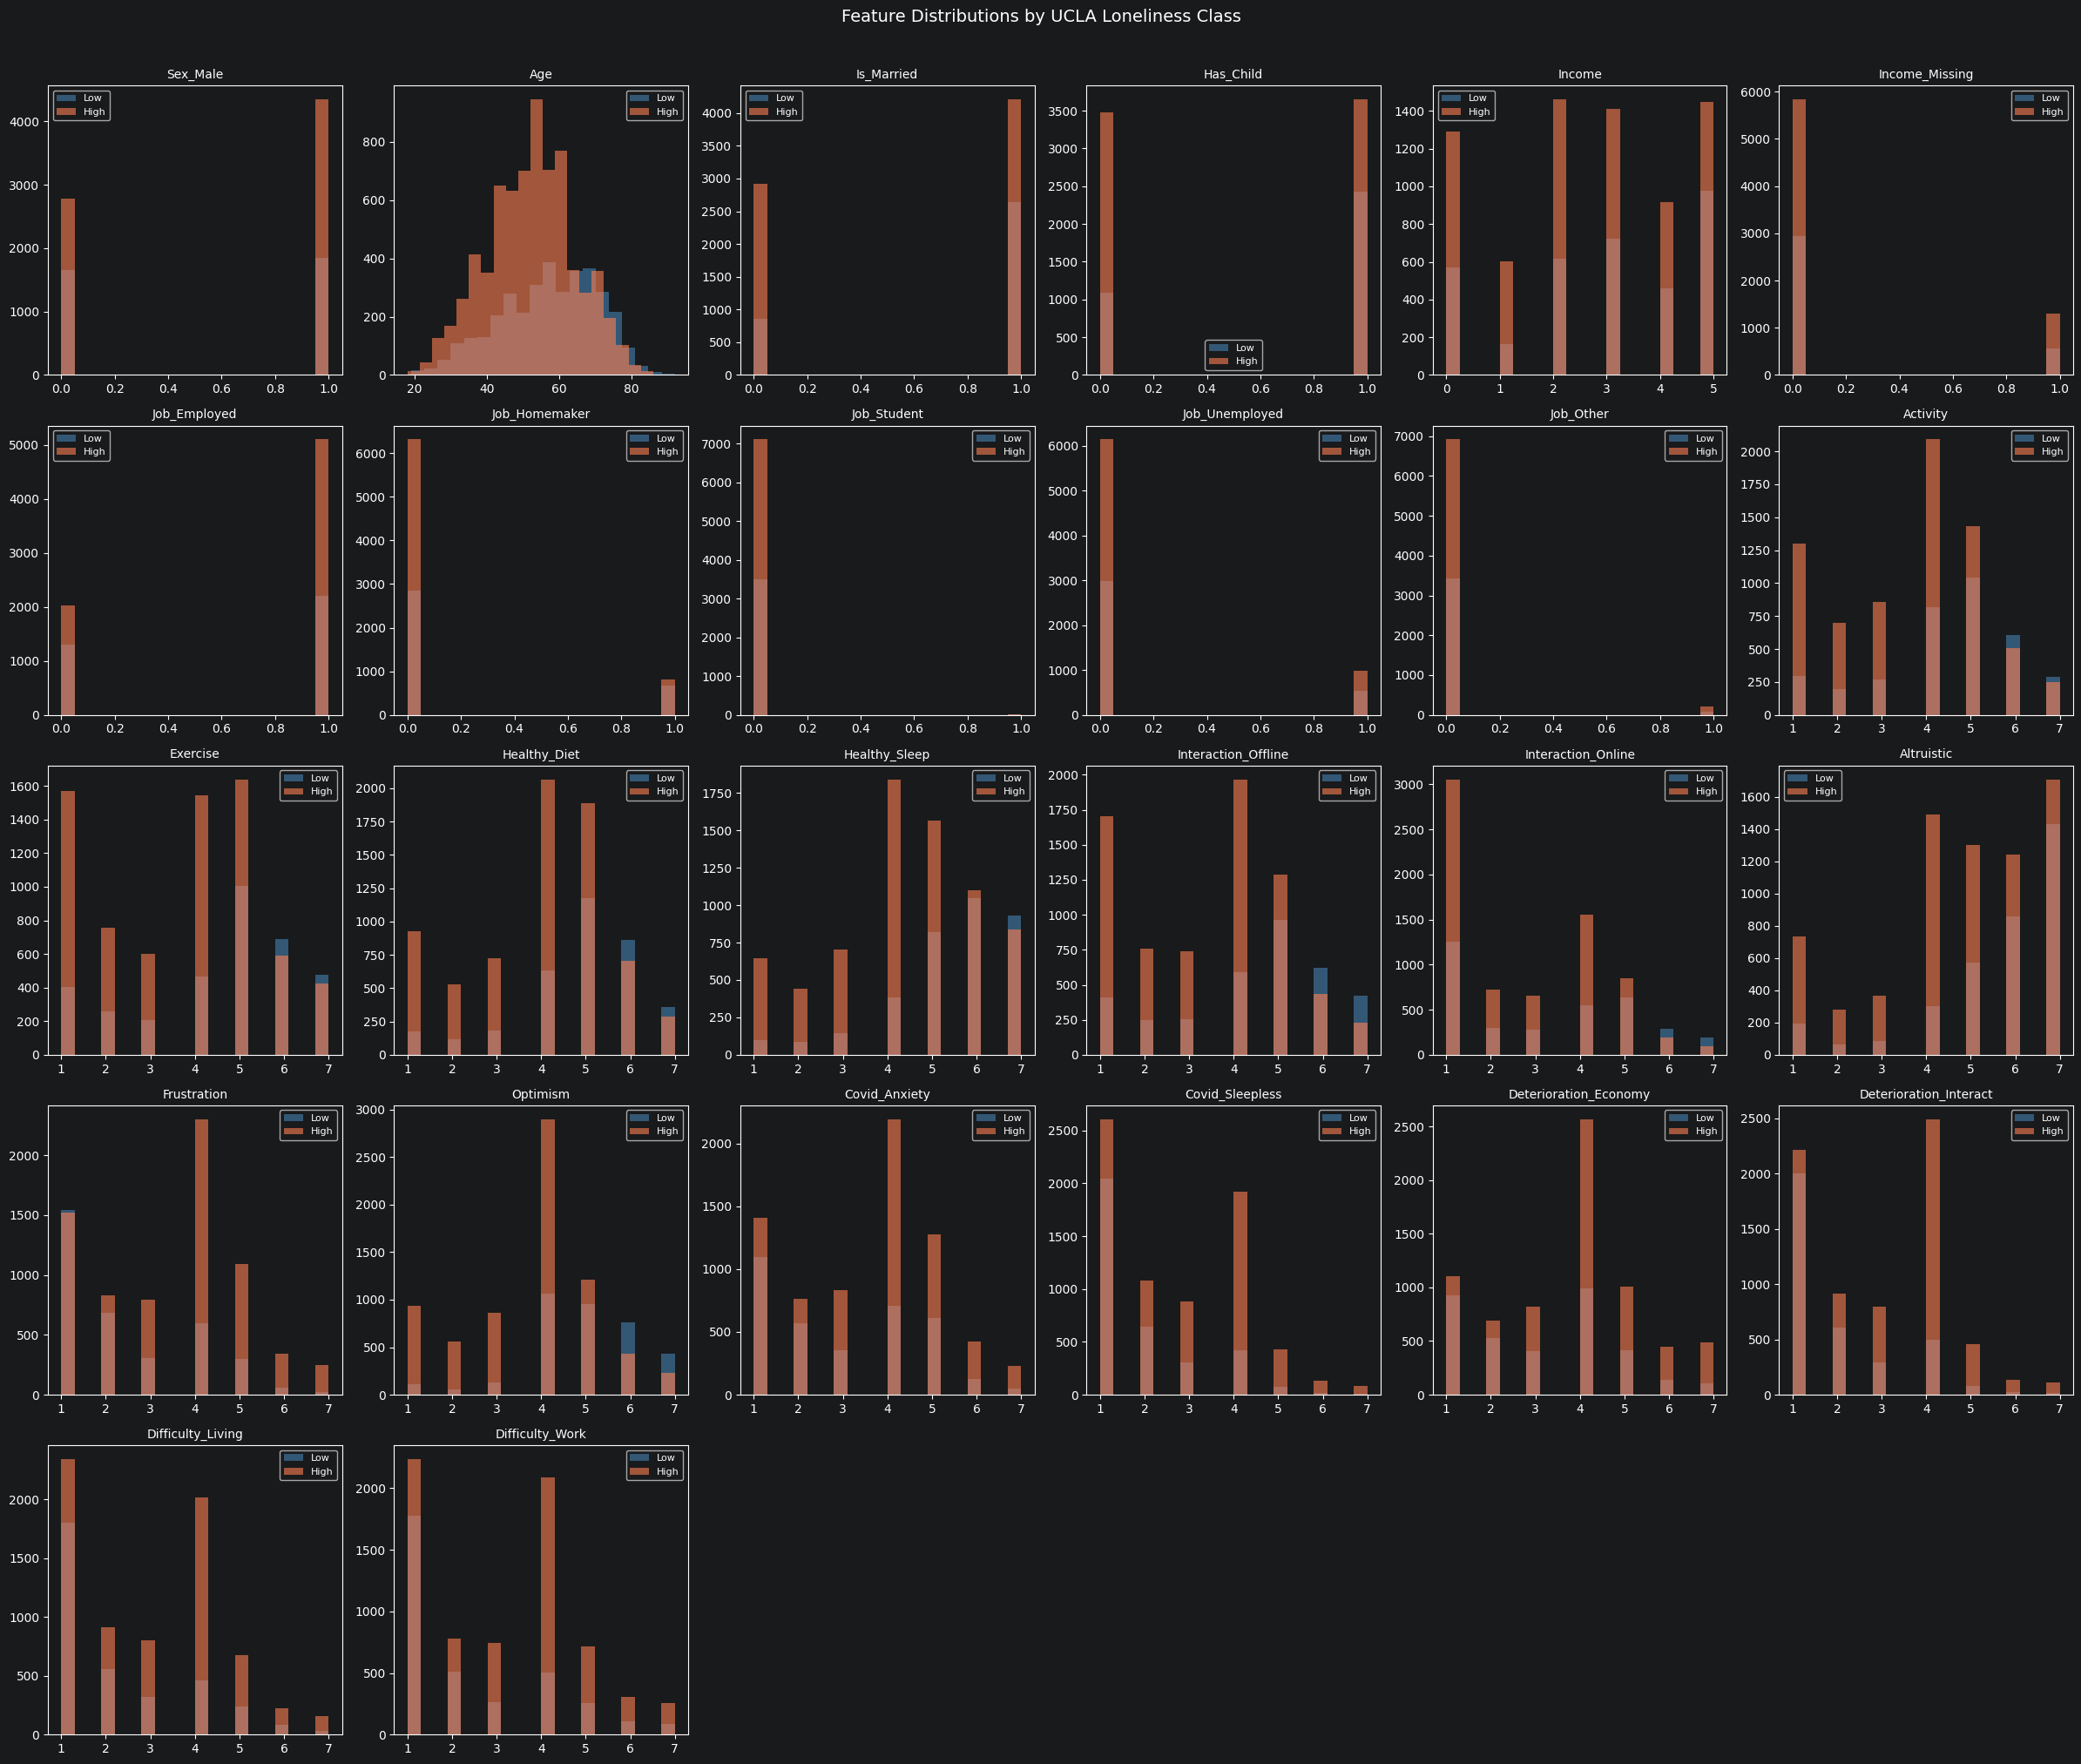

Saved: plots/feature_distributions.png


In [15]:
# Feature distributions by target class
fig, axes = plt.subplots(5, 6, figsize=(24, 20))
axes = axes.flatten()

for i, feat in enumerate(features_UCLA):
    if i < len(axes):
        for label, color in zip([0, 1], ["steelblue", "coral"]):
            subset = df_encoded[df_encoded[target_UCLA] == label][feat]
            axes[i].hist(subset, bins=20, alpha=0.6, color=color,
                        label="Low" if label == 0 else "High")
        axes[i].set_title(feat, fontsize=10)
        axes[i].legend(fontsize=8)

for j in range(len(features_UCLA), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by UCLA Loneliness Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("plots/feature_distributions.png", dpi=150, bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print("Saved: plots/feature_distributions.png")

## Feature Distributions Across Survey Phases

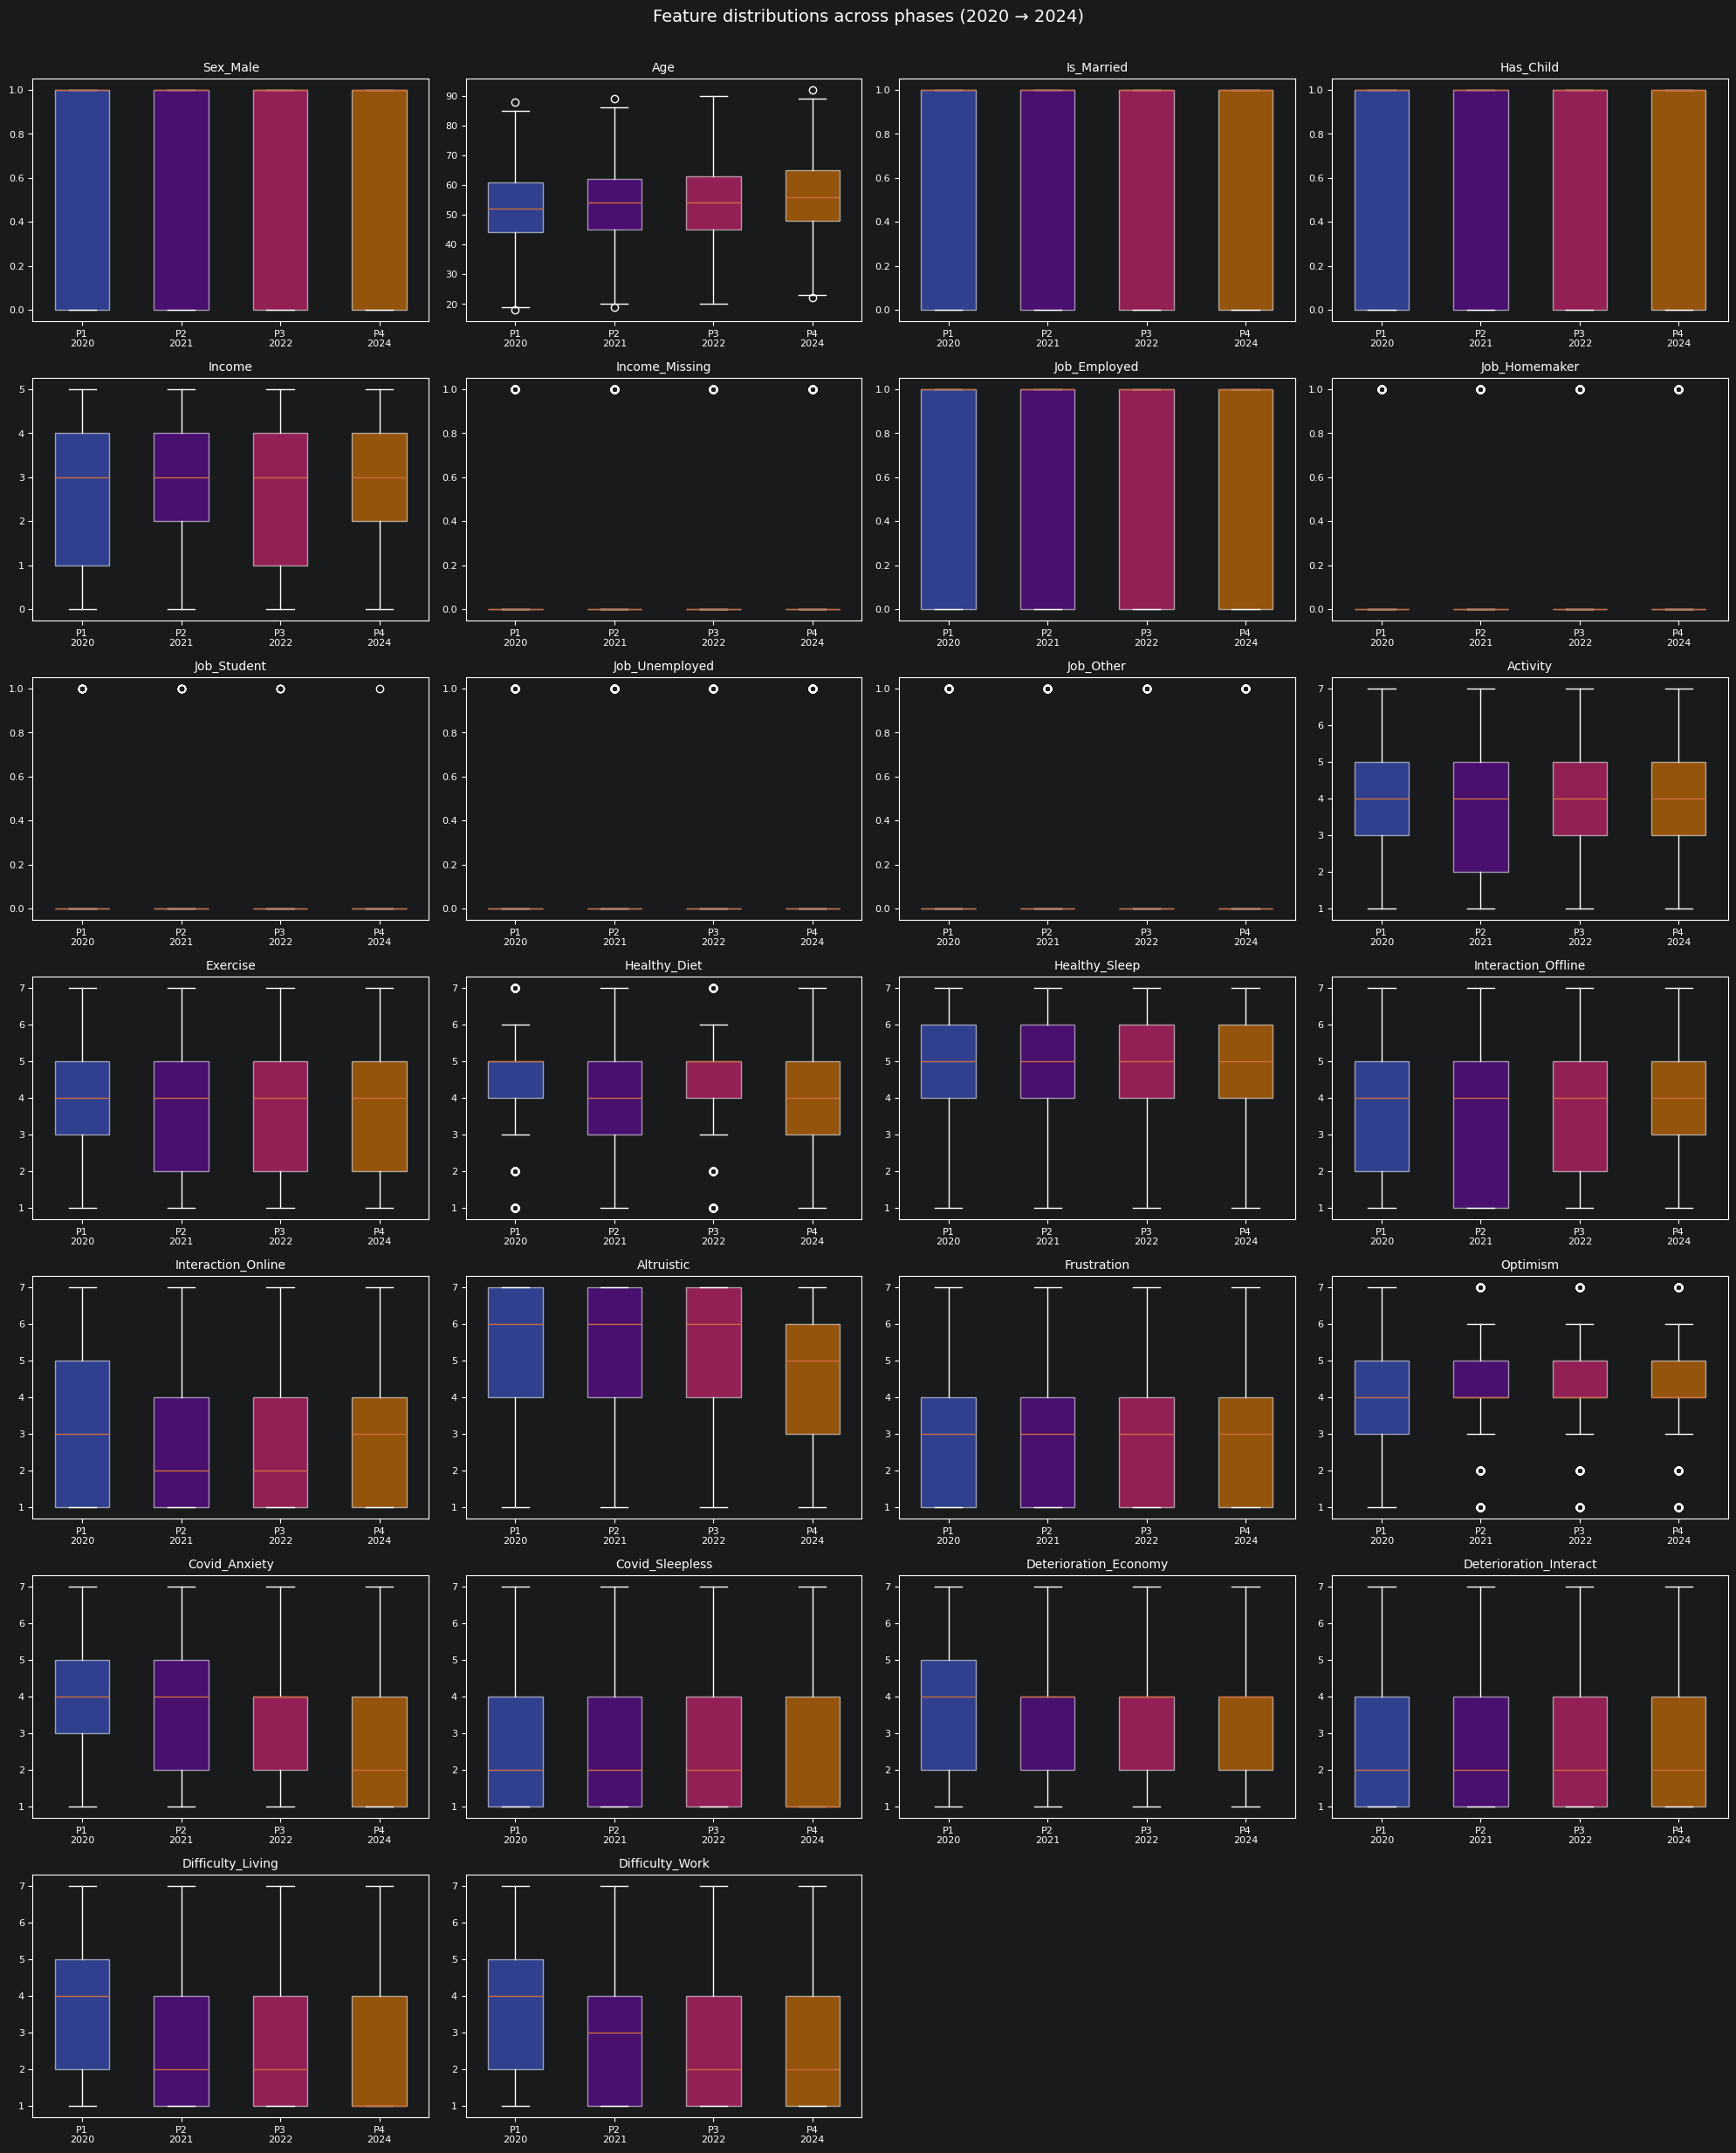

Saved: plots/feature_distributions_by_phase.png


In [16]:
# Feature distributions across phases — boxplots, one per feature
phase_palette = {1: "#4361ee", 2: "#7209b7",
                 3: "#f72585", 4: "#fb8500"}
n_cols = 4
n_rows = (len(features_UCLA) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(features_UCLA):
    ax = axes[i]
    data_per_phase = [
        df_encoded[df_encoded["Phase"] == p][feat].values
        for p in [1, 2, 3, 4]
    ]
    bplot = ax.boxplot(
        data_per_phase, patch_artist=True,
        labels=["P1\n2020", "P2\n2021", "P3\n2022", "P4\n2024"],
        widths=0.55,
    )
    for patch, p in zip(bplot["boxes"], [1, 2, 3, 4]):
        patch.set_facecolor(phase_palette[p])
        patch.set_alpha(0.55)
    ax.set_title(feat, fontsize=10)
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

for j in range(len(features_UCLA), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature distributions across phases (2020 \u2192 2024)",
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig("plots/feature_distributions_by_phase.png", dpi=150,
            bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print("Saved: plots/feature_distributions_by_phase.png")


In [17]:
# Per-phase feature means — small-multiples line chart for trend at a glance
mean_by_phase = (
    df_encoded.groupby("Phase")[features_UCLA].mean().T
)
mean_by_phase.columns = [f"Phase {int(c)}" for c in mean_by_phase.columns]
mean_by_phase["Display Name"] = [
    FEATURE_DISPLAY_NAMES.get(f, f) for f in mean_by_phase.index
]
mean_long = mean_by_phase.reset_index().melt(
    id_vars=["index", "Display Name"],
    value_vars=[f"Phase {p}" for p in [1, 2, 3, 4]],
    var_name="Phase", value_name="Mean",
).rename(columns={"index": "Feature"})

fig = px.line(
    mean_long, x="Phase", y="Mean", color="Feature",
    facet_col="Display Name", facet_col_wrap=4,
    title="Per-feature mean across phases",
    height=140 * ((len(features_UCLA) + 3) // 4),
    markers=True,
)
fig.update_layout(showlegend=False)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1],
                                            font_size=10))
fig.for_each_yaxis(lambda y: y.update(matches=None, showticklabels=True,
                                       tickfont=dict(size=8)))
fig.show()

print("\nMean of each feature by phase:")
display(mean_by_phase.set_index("Display Name").drop(columns=[]))



Mean of each feature by phase:


,Phase 1,Phase 2,Phase 3,Phase 4
Display Name,,,,
Sex,0.582926,0.582926,0.582926,0.582926
Age,52.038360,53.125235,53.962016,56.038736
Marital Status,0.646108,0.644979,0.641595,0.644603
Has Children,0.562241,0.572772,0.569011,0.579917
Household Income,2.702144,2.725461,2.730350,2.724709
Income Missing,0.191049,0.175630,0.165476,0.167356
Employed,0.696502,0.691237,0.686348,0.676946
Homemaker,0.140654,0.141030,0.139150,0.135765
Student,0.005265,0.002633,0.001504,0.000376


High Loneliness rate by phase:


,High_Loneliness_Rate
Phase,
1,0.663031
2,0.679955
3,0.681083
4,0.656638


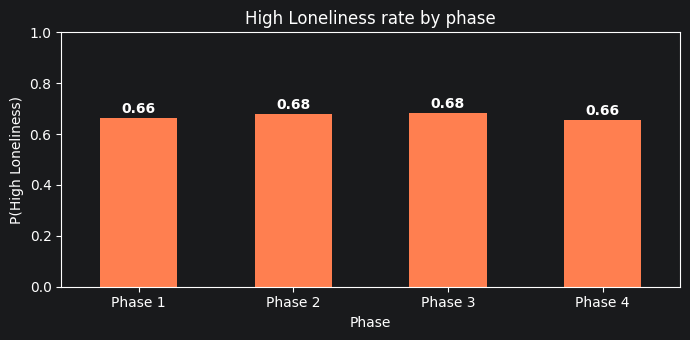

Saved: plots/target_rate_by_phase.png


In [18]:
# Target rate (High Loneliness) per phase
target_rate_phase = (
    df_encoded.groupby("Phase")[target_UCLA].mean().rename("High_Loneliness_Rate")
)
target_count_phase = (
    df_encoded.groupby("Phase")[target_UCLA].value_counts().unstack(fill_value=0)
)
print("High Loneliness rate by phase:")
display(target_rate_phase.to_frame())

ax = target_rate_phase.plot(kind="bar", color="coral", figsize=(7, 3.5))
ax.set_title("High Loneliness rate by phase")
ax.set_ylabel("P(High Loneliness)")
ax.set_ylim(0, 1)
ax.set_xticklabels([f"Phase {int(p)}" for p in target_rate_phase.index],
                   rotation=0)
for i, v in enumerate(target_rate_phase.values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("plots/target_rate_by_phase.png", dpi=150,
            bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print("Saved: plots/target_rate_by_phase.png")


# Train-Test Split

In [19]:
df_ml = df_encoded.copy()
df_train = df_ml[df_ml["Phase"].isin([1, 2, 3])].copy()
df_test = df_ml[df_ml["Phase"] == 4].copy()

ignore_feats = vars_UCLA
X_train = df_train.drop(columns=[target_UCLA] + ignore_feats, errors="ignore")
y_train = df_train[target_UCLA]
X_test = df_test.drop(columns=[target_UCLA] + ignore_feats, errors="ignore")
y_test = df_test[target_UCLA]

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing set:  {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set: 7977 samples, 26 features
Testing set:  2659 samples, 26 features

Training target distribution:
UCLA_High
1    5382
0    2595
Name: count, dtype: int64

Test target distribution:
UCLA_High
1    1746
0     913
Name: count, dtype: int64


# Baseline Model Training

In [20]:
if LOAD_SAVED_MODEL and os.path.exists("models/tabpfn.joblib"):
    model = joblib.load("models/tabpfn.joblib")
    print(f"Loaded saved TabPFN model from models/tabpfn.joblib")
    print(f"Type: {type(model).__name__}")
else:
    # Define all models with default hyperparameters
    models = [
        ("TabPFN", TabPFNClassifier(device=device, random_state=random_state)),
    ]

Loaded saved TabPFN model from models/tabpfn.joblib
Type: TabPFNClassifier


In [21]:
if not LOAD_SAVED_MODEL or not os.path.exists("models/tabpfn.joblib"):
    # Train and evaluate all baseline models
    results = []
    trained_models = {}
    cm_data = {}

    for name, mdl in models:
        print(f"\n{'='*60}")
        print(f"  {name} (baseline)")
        print(f"{'='*60}")

        start_train = time.time()
        mdl.fit(X_train, y_train)
        train_time = time.time() - start_train

        start_test = time.time()
        y_pred = mdl.predict(X_test)
        test_time = time.time() - start_test

        y_prob = mdl.predict_proba(X_test)[:, 1] if hasattr(mdl, "predict_proba") else y_pred

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        print(f"  Accuracy: {acc:.4f}")
        print(f"  F1-Score: {f1:.4f}")
        print(f"  ROC AUC:  {auc:.4f}")
        print(f"  Train:    {format_time(train_time)}")
        print(f"  Predict:  {format_time(test_time)}")
        print(f"\n{classification_report(y_test, y_pred, target_names=['Low', 'High'])}")

        results.append({
            "Model": name, "Accuracy": acc, "F1-Score": f1,
            "ROC AUC": auc, "Train Time (s)": train_time,
            "Test Time (s)": test_time
        })
        trained_models[name] = mdl
        cm_data[name] = confusion_matrix(y_test, y_pred)

    df_results = pd.DataFrame(results)
    model = trained_models["TabPFN"]
    print("\nAll baseline models trained.")
else:
    # Evaluate loaded model
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cm_data = {"TabPFN": confusion_matrix(y_test, y_pred)}
    print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}, AUC-ROC: {auc:.4f}")


Accuracy: 0.7789, F1: 0.8396, AUC-ROC: 0.8424


# Results & Comparison

In [22]:
# Confusion matrices
for name in cm_data:
    cm = cm_data[name]
    fig_cm = ff.create_annotated_heatmap(
        z=cm.tolist(),
        x=["Predicted Low", "Predicted High"],
        y=["Actual Low", "Actual High"],
        annotation_text=[[str(y) for y in x] for x in cm.tolist()],
        colorscale="Viridis"
    )
    fig_cm.update_layout(title_text=f"Confusion Matrix (Baseline): {name}",
                         yaxis=dict(autorange="reversed"), height=350)
    fig_cm.show()

# Save Models & Results

In [23]:
if not LOAD_SAVED_MODEL or not os.path.exists("models/tabpfn.joblib"):
    # Save all models
    for name, model in trained_models.items():
        safe_name = name.lower().replace(" ", "_").replace("-", "_")
        save_path = f"models/{safe_name}.joblib"
        joblib.dump(model, save_path)
        print(f"Saved: {save_path}")

    # Save results
    df_results.to_csv("models/baseline_results.csv", index=False)
    print("\nBaseline results saved to models/baseline_results.csv")

    # Save training data
    X_train.to_csv("artifacts/X_train.csv", index=False)
    X_test.to_csv("artifacts/X_test.csv", index=False)
    y_train.to_csv("artifacts/y_train.csv", index=False)
    y_test.to_csv("artifacts/y_test.csv", index=False)
    print("Training/test data saved.")
else:
    print("Models already trained.")

Models already trained.


# SHAP Explanations (TreeSHAP via LightGBM Surrogate)

https://arxiv.org/html/2510.08739v1

In [24]:
# Train LightGBM surrogate to mimic TabPFN's predicted probabilities

print("Building LightGBM surrogate of TabPFN...")
start_time = time.time()

# Get TabPFN's predictions
tabpfn_train_probs = model.predict_proba(X_train)[:, 1]
tabpfn_test_probs = model.predict_proba(X_test)[:, 1]

# Train surrogate to reproduce TabPFN's probability ranking
surrogate_labels_train = (tabpfn_train_probs >= 0.5).astype(int)
surrogate_labels_test = (tabpfn_test_probs >= 0.5).astype(int)

# Try lang sa hyperparameters haha
surrogate = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=random_state,
    verbose=-1,
)

# Weight samples by how confident TabPFN is (emphasize high-confidence predictions)
weights = np.abs(tabpfn_train_probs - 0.5) + 0.5  # range [0.5, 1.0]
surrogate.fit(X_train, surrogate_labels_train, sample_weight=weights)

# Validate surrogate fidelity
surr_train_probs = surrogate.predict_proba(X_train)[:, 1]
surr_test_probs = surrogate.predict_proba(X_test)[:, 1]


# Agreement metrics
train_agreement = (surrogate.predict(X_train) == surrogate_labels_train).mean()
test_agreement = (surrogate.predict(X_test) == surrogate_labels_test).mean()
rank_corr_train, _ = spearmanr(tabpfn_train_probs, surr_train_probs)
rank_corr_test, _ = spearmanr(tabpfn_test_probs, surr_test_probs)

elapsed = time.time() - start_time
print(f"Surrogate trained in {format_time(elapsed)}")
print(f"\nSurrogate fidelity (does it mimic TabPFN?):")
print(f"  Train agreement: {train_agreement:.4f}")
print(f"  Test agreement:  {test_agreement:.4f}")
print(f"  Rank correlation (train): {rank_corr_train:.4f}")
print(f"  Rank correlation (test):  {rank_corr_test:.4f}")

if test_agreement < 0.90:
    print("\nSurrogate fidelity is low...")
else:
    print("\n✓ Surrogate closely mimics TabPFN — TreeSHAP values are reliable.")

Building LightGBM surrogate of TabPFN...
Surrogate trained in 20.87s

Surrogate fidelity (does it mimic TabPFN?):
  Train agreement: 1.0000
  Test agreement:  0.9669
  Rank correlation (train): 0.9742
  Rank correlation (test):  0.9786

✓ Surrogate closely mimics TabPFN — TreeSHAP values are reliable.


In [25]:
# Create TreeExplainer on the surrogate
print("Initializing SHAP TreeExplainer on surrogate...")
start_time = time.time()

shap_explainer = shap.TreeExplainer(surrogate)

elapsed = time.time() - start_time
print(f"TreeExplainer ready in {format_time(elapsed)}")

Initializing SHAP TreeExplainer on surrogate...
TreeExplainer ready in 0.19s


In [26]:
# Compute SHAP values on ALL test samples — TreeSHAP is exact and fast
X_explain = X_test.copy()

print(f"Computing TreeSHAP values for ALL {len(X_explain)} test samples...")
start_time = time.time()

shap_values_raw = shap_explainer.shap_values(X_explain)

elapsed = time.time() - start_time
print(f"SHAP values computed in {format_time(elapsed)}")

# Ensure consistent format for downstream cells
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw  # Already [class0_2d, class1_2d]
    print(f"Shape: class 0 = {shap_values[0].shape}, class 1 = {shap_values[1].shape}")
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    # (n_samples, n_features, n_classes) → list of 2D
    shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
    print(f"Shape: class 0 = {shap_values[0].shape}, class 1 = {shap_values[1].shape}")
else:
    # Single output (regression-style) — wrap for binary
    shap_values = [-shap_values_raw, shap_values_raw]
    print(f"Shape: {shap_values[0].shape} (mirrored for binary)")

print(f"\nExpected values: {shap_explainer.expected_value}")


Computing TreeSHAP values for ALL 2659 test samples...
SHAP values computed in 0.88s
Shape: (2659, 26) (mirrored for binary)

Expected values: 5.918845348695789


## Surrogate Model Exploration

In [27]:
# Compare surrogate models for TabPFN fidelity

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed — skipping.')

print('Benchmarking surrogate models...')

surrogate_candidates = {
    "LightGBM": LGBMClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        random_state=random_state, verbose=-1,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=500, max_depth=10,
        random_state=random_state, n_jobs=-1,
    ),
    "DecisionTree": DecisionTreeClassifier(
        max_depth=10, random_state=random_state,
    ),
    "LogisticRegression": Pipeline([
        ("scale", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=2000, random_state=random_state)),
    ]),
    "XGBoost": XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=random_state,
        eval_metric="logloss", verbosity=0,
    ),
}
surrogate_results = []
trained_surrogates = {}

for name, candidate in surrogate_candidates.items():
    t0 = time.time()
    if name == "LogisticRegression":
        candidate.fit(X_train, surrogate_labels_train)
    else:
        candidate.fit(X_train, surrogate_labels_train, sample_weight=weights)
    fit_t = time.time() - t0

    train_p = candidate.predict_proba(X_train)[:, 1]
    test_p = candidate.predict_proba(X_test)[:, 1]
    train_agree = (candidate.predict(X_train) == surrogate_labels_train).mean()
    test_agree = (candidate.predict(X_test) == surrogate_labels_test).mean()
    rho_train, _ = spearmanr(tabpfn_train_probs, train_p)
    rho_test, _ = spearmanr(tabpfn_test_probs, test_p)

    surrogate_results.append({
        "Surrogate": name,
        "Train Agreement": train_agree,
        "Test Agreement": test_agree,
        "Rank Corr (Train)": rho_train,
        "Rank Corr (Test)": rho_test,
        "Fit Time (s)": fit_t,
    })
    trained_surrogates[name] = candidate
    print(f"  {name}: test_agree={test_agree:.4f}, rank_corr={rho_test:.4f}, fit={fit_t:.2f}s")

df_surrogate = pd.DataFrame(surrogate_results).sort_values("Test Agreement", ascending=False)
print("\n=== Surrogate Fidelity ===")
display(df_surrogate)

best_surrogate_name = df_surrogate.iloc[0]["Surrogate"]
print(f"\nBest surrogate overall: {best_surrogate_name}")


Benchmarking surrogate models...
  LightGBM: test_agree=0.9669, rank_corr=0.9786, fit=0.18s
  RandomForest: test_agree=0.9440, rank_corr=0.9256, fit=0.50s
  DecisionTree: test_agree=0.8954, rank_corr=0.7320, fit=0.02s
  LogisticRegression: test_agree=0.9616, rank_corr=0.9660, fit=0.01s
  XGBoost: test_agree=0.9725, rank_corr=0.9758, fit=0.23s

=== Surrogate Fidelity ===


,Surrogate,Train Agreement,Test Agreement,Rank Corr (Train),Rank Corr (Test),Fit Time (s)
4,XGBoost,1.000000,0.972546,0.968842,0.975782,0.232076
0,LightGBM,1.000000,0.966905,0.974188,0.978573,0.175946
3,LogisticRegression,0.945092,0.961640,0.960732,0.966036,0.008241
1,RandomForest,0.986336,0.943964,0.928172,0.925646,0.504164
2,DecisionTree,0.967782,0.895449,0.771616,0.732047,0.024030



Best surrogate overall: XGBoost


In [28]:
# Visualize surrogate fidelity
fig = px.bar(df_surrogate, x="Surrogate", y="Test Agreement",
             color="Surrogate",
             title="Surrogate Model Fidelity to TabPFN (Test Agreement)",
             text_auto=".4f")
fig.update_layout(yaxis_range=[0, 1], showlegend=False)
fig.show()

fig = px.bar(df_surrogate, x="Surrogate", y="Rank Corr (Test)",
             color="Surrogate",
             title="Surrogate Rank Correlation with TabPFN Probabilities (Test)",
             text_auto=".4f")
fig.update_layout(yaxis_range=[0, 1], showlegend=False)
fig.show()


In [29]:
# Promote the best TREE-BASED surrogate for downstream TreeSHAP
TREE_SURROGATES = {"LightGBM", "RandomForest", "DecisionTree", "XGBoost"}
tree_only = df_surrogate[df_surrogate["Surrogate"].isin(TREE_SURROGATES)]
best_tree_surrogate_name = tree_only.iloc[0]["Surrogate"]

if best_tree_surrogate_name != best_surrogate_name:
    print(f"Best overall surrogate is {best_surrogate_name}, "
          f"but TreeSHAP requires a tree model. Using {best_tree_surrogate_name}.")
else:
    print(f"Best surrogate is tree-based ({best_tree_surrogate_name}) — TreeSHAP-ready.")

surrogate = trained_surrogates[best_tree_surrogate_name]
shap_explainer = shap.TreeExplainer(surrogate)
shap_values_raw = shap_explainer.shap_values(X_explain)

if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
else:
    shap_values = [-shap_values_raw, shap_values_raw]

expected_value = shap_explainer.expected_value
if isinstance(expected_value, list):
    expected_value = np.array(expected_value)
elif isinstance(expected_value, (int, float)):
    expected_value = np.array([-expected_value, expected_value])

print(f"\nDownstream SHAP analysis now uses: {best_tree_surrogate_name}")
print(f"SHAP values shape: {shap_values[0].shape} (per class)")

# Persist the upgraded surrogate so the dashboard sees the same artifacts
joblib.dump(surrogate, "models/surrogate.joblib")
with open("explainers/shap_values_test.pkl", "wb") as f:
    pickle.dump(shap_values, f)
with open("explainers/shap_expected_value.pkl", "wb") as f:
    pickle.dump(expected_value, f)


Best surrogate is tree-based (XGBoost) — TreeSHAP-ready.

Downstream SHAP analysis now uses: XGBoost
SHAP values shape: (2659, 26) (per class)


## Global Feature Importance

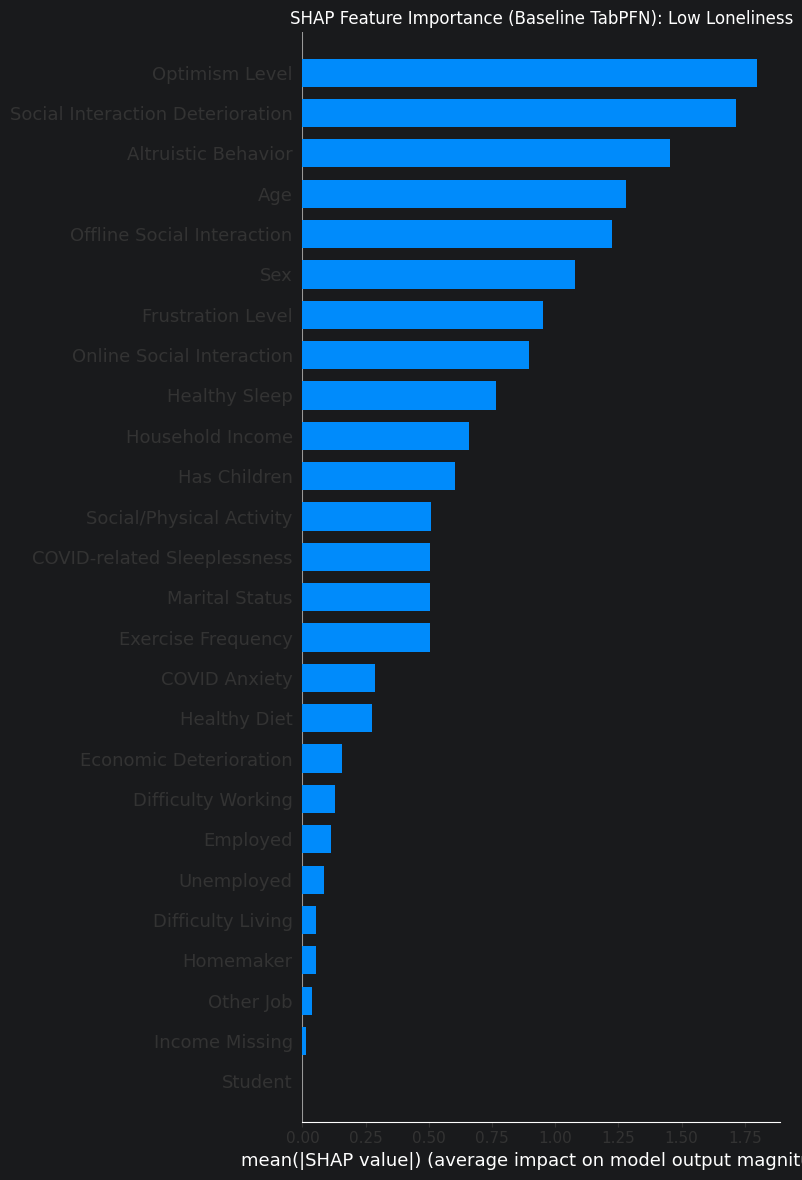

Saved: plots/shap/importance_low_loneliness.png


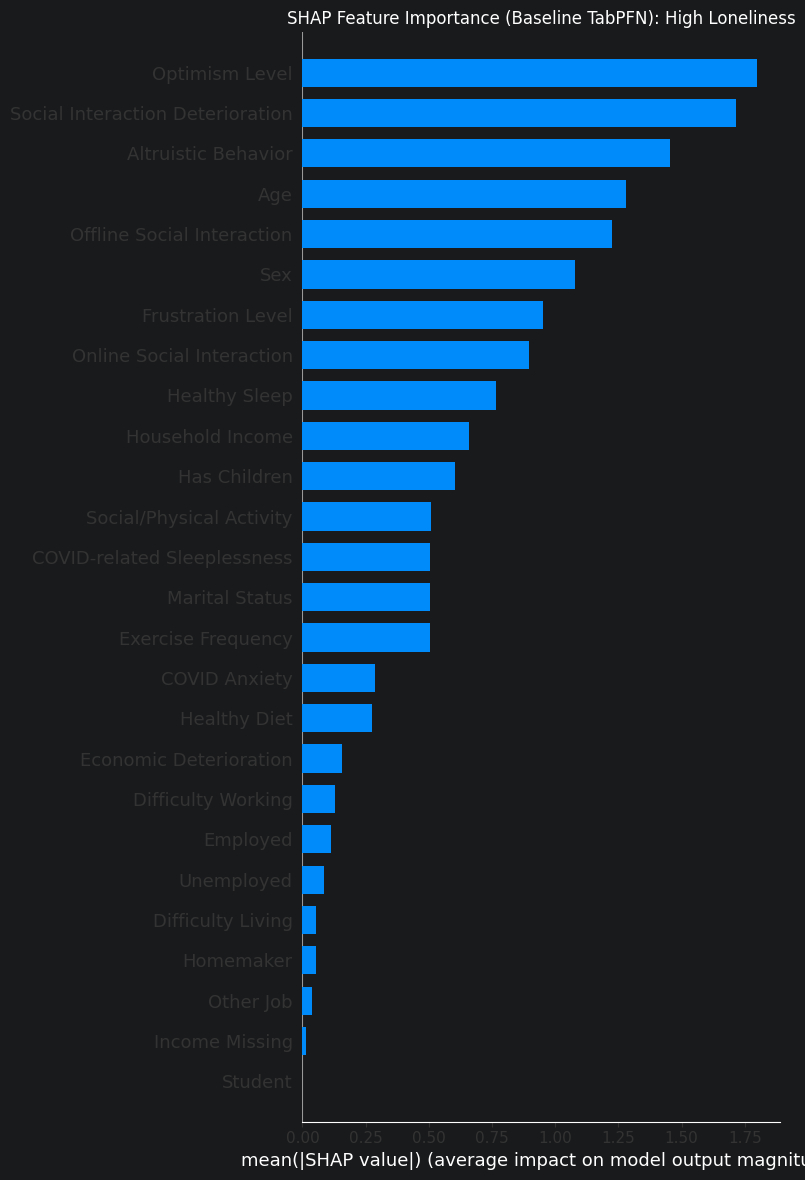

Saved: plots/shap/importance_high_loneliness.png


In [30]:
features_list = X_train.columns.tolist()
display_names_list = get_display_names_list(features_list)
n_features = len(features_list)
class_names = ["Low Loneliness", "High Loneliness"]

for i, class_name in enumerate(class_names):
    fig, ax = plt.subplots(figsize=(10, max(8, n_features * 0.35)))
    shap.summary_plot(shap_values[i], X_explain,
                      feature_names=display_names_list, plot_type="bar",
                      show=False, max_display=n_features)
    plt.title(f"SHAP Feature Importance (Baseline TabPFN): {class_name}")
    plt.tight_layout()
    safe_name = class_name.lower().replace(" ", "_")
    plt.savefig(f"plots/shap/importance_{safe_name}.png", dpi=150, bbox_inches="tight", facecolor="white", edgecolor="none")
    plt.show()
    print(f"Saved: plots/shap/importance_{safe_name}.png")


## Feature Effects

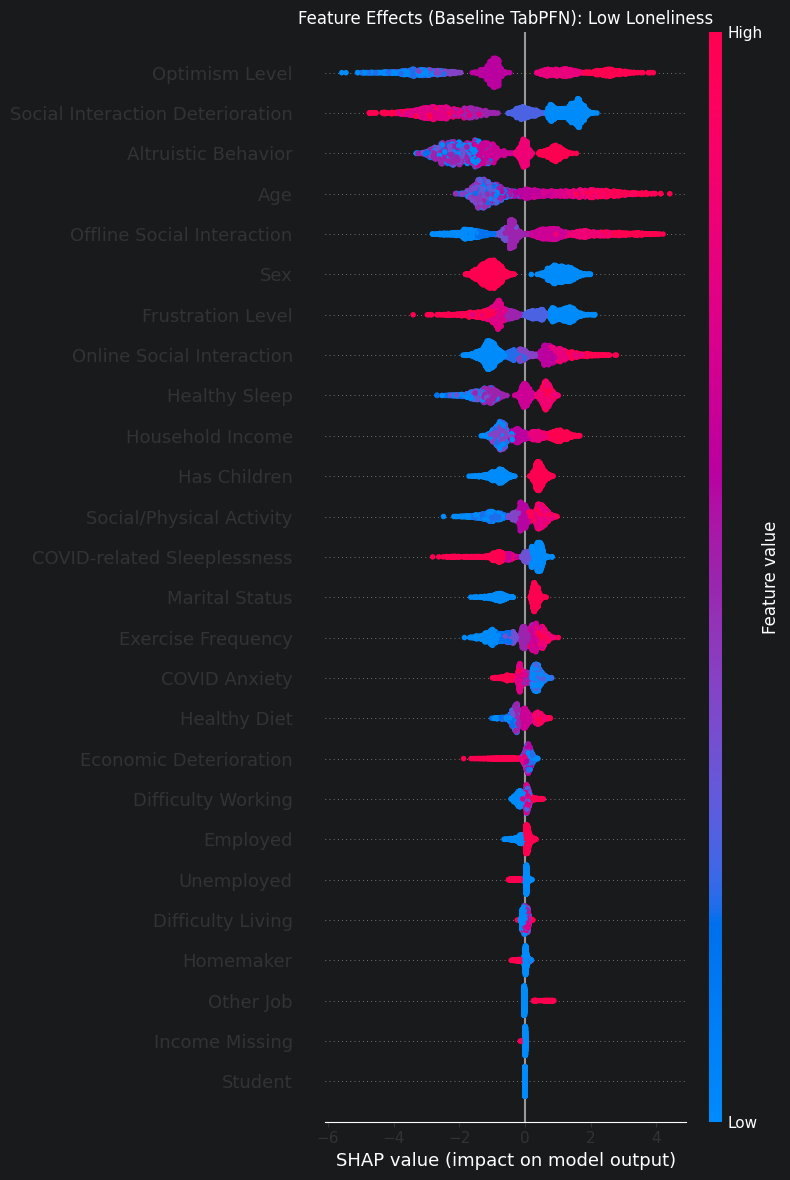

Saved: plots/shap/effects_low_loneliness.png


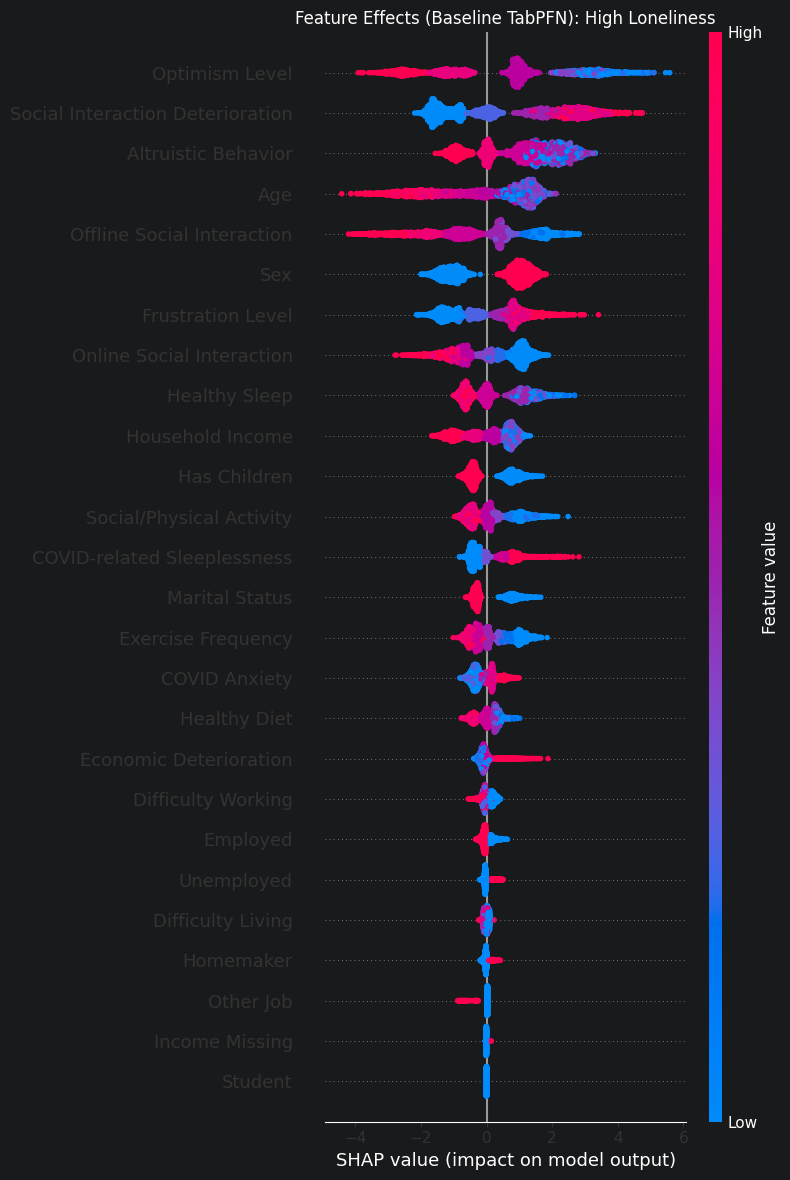

Saved: plots/shap/effects_high_loneliness.png


In [31]:
for i, class_name in enumerate(class_names):
    fig, ax = plt.subplots(figsize=(10, max(8, n_features * 0.35)))
    shap.summary_plot(shap_values[i], X_explain,
                      feature_names=display_names_list,
                      show=False, max_display=n_features)
    plt.title(f"Feature Effects (Baseline TabPFN): {class_name}")
    plt.tight_layout()
    safe_name = class_name.lower().replace(" ", "_")
    plt.savefig(f"plots/shap/effects_{safe_name}.png", dpi=150, bbox_inches="tight", facecolor="white", edgecolor="none")
    plt.show()
    print(f"Saved: plots/shap/effects_{safe_name}.png")


## Dependence Plots

All 26 features by mean |SHAP| (High Loneliness):
  1. Optimism Level = 1.7991
  2. Social Interaction Deterioration = 1.7145
  3. Altruistic Behavior = 1.4530
  4. Age = 1.2799
  5. Offline Social Interaction = 1.2262
  6. Sex = 1.0798
  7. Frustration Level = 0.9511
  8. Online Social Interaction = 0.8969
  9. Healthy Sleep = 0.7655
  10. Household Income = 0.6595
  11. Has Children = 0.6030
  12. Social/Physical Activity = 0.5069
  13. COVID-related Sleeplessness = 0.5059
  14. Marital Status = 0.5040
  15. Exercise Frequency = 0.5033
  16. COVID Anxiety = 0.2854
  17. Healthy Diet = 0.2733
  18. Economic Deterioration = 0.1583
  19. Difficulty Working = 0.1293
  20. Employed = 0.1109
  21. Unemployed = 0.0857
  22. Difficulty Living = 0.0541
  23. Homemaker = 0.0517
  24. Other Job = 0.0370
  25. Income Missing = 0.0124
  26. Student = 0.0000


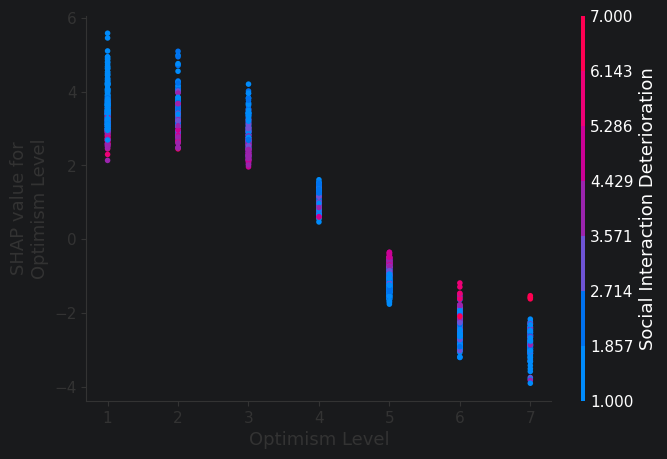

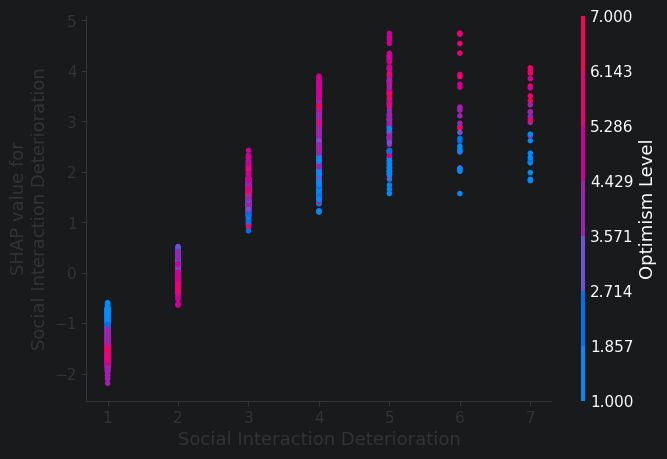

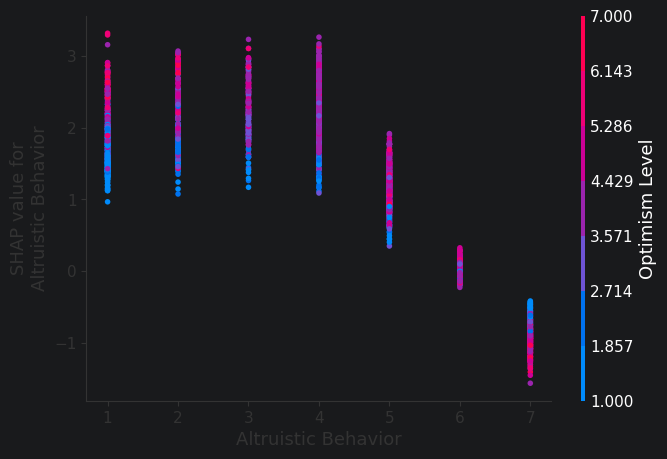

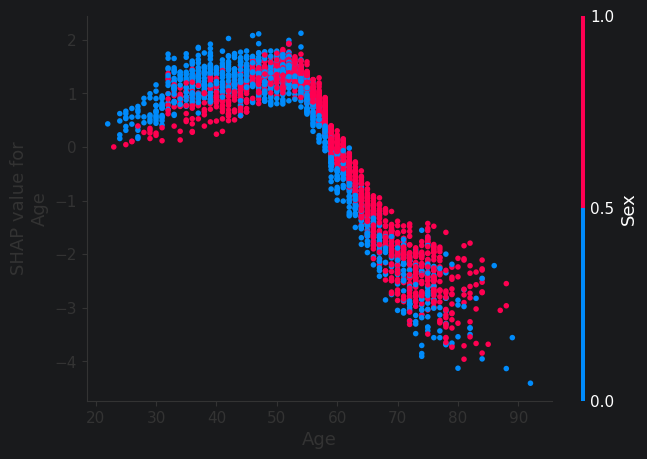

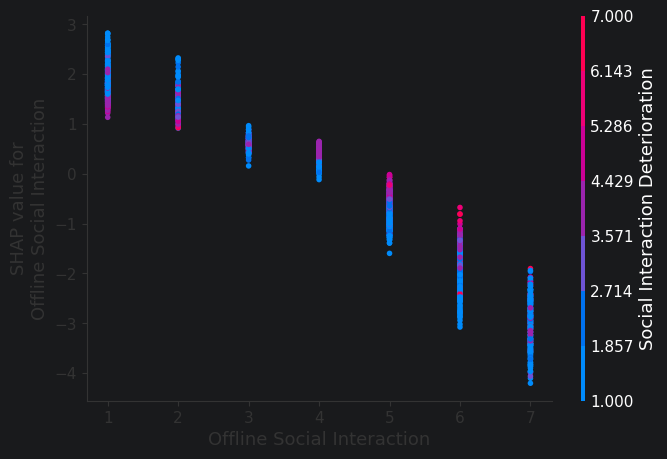

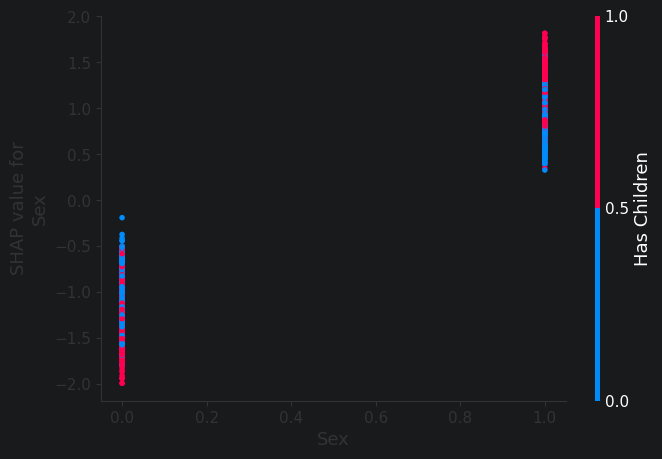

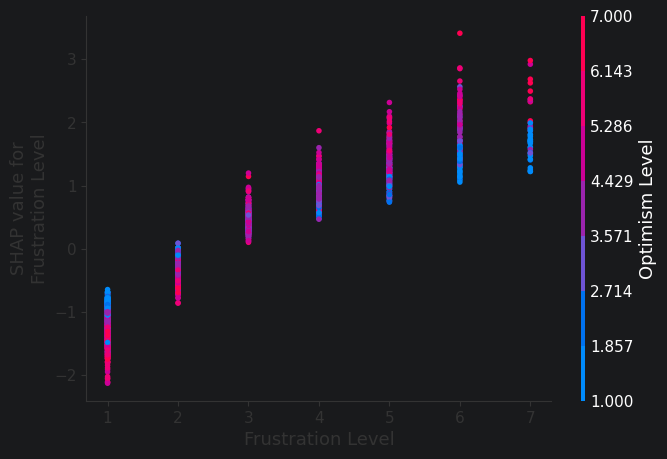

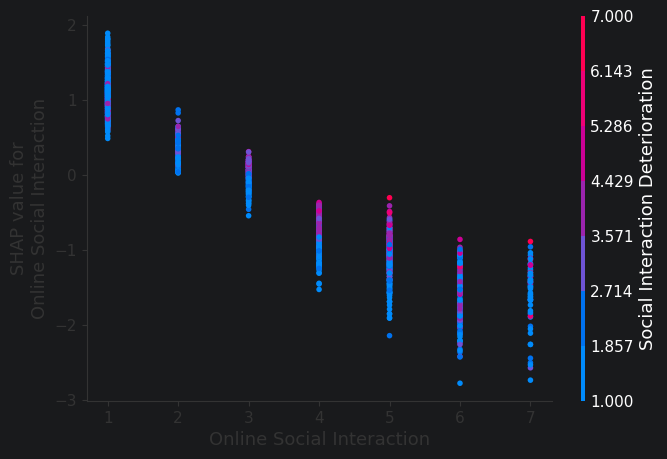

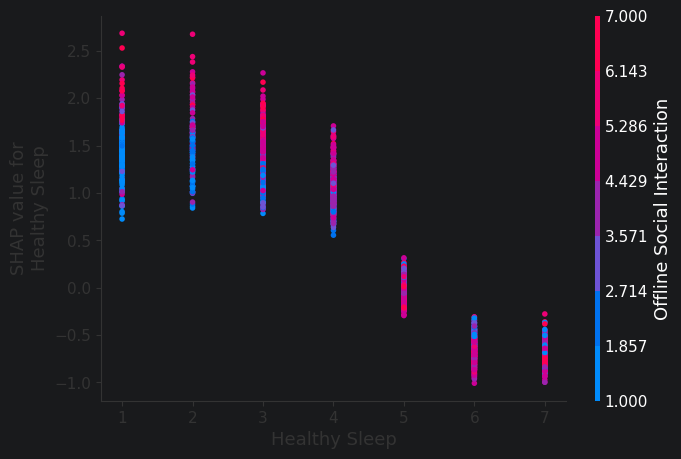

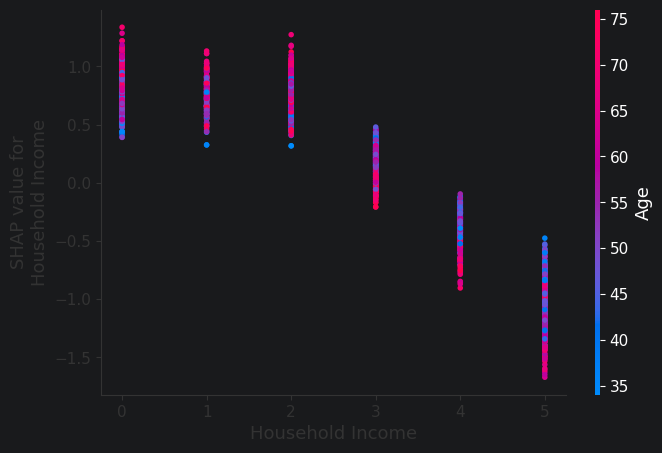

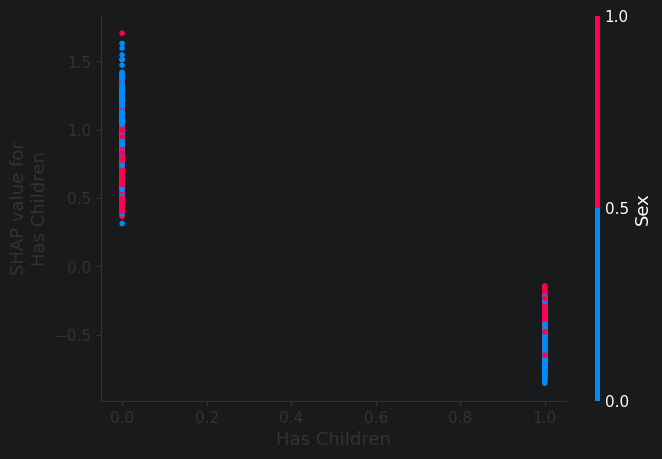

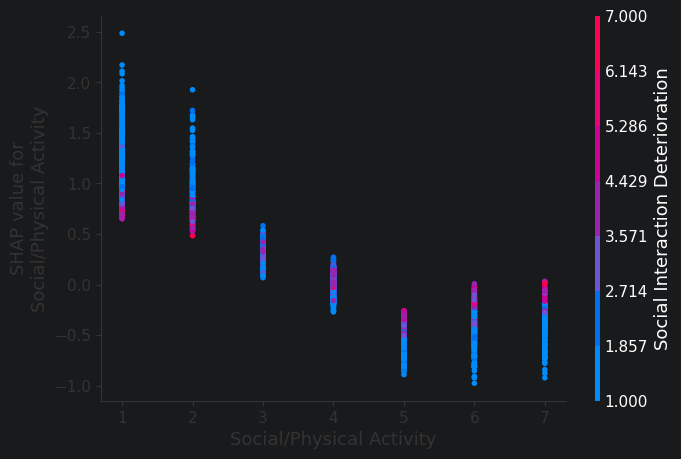

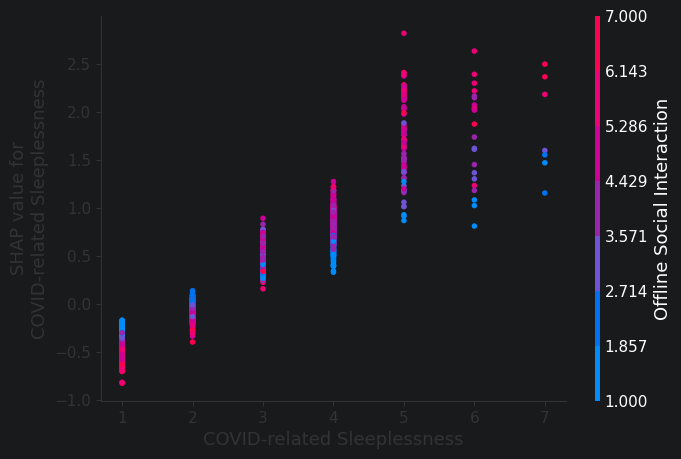

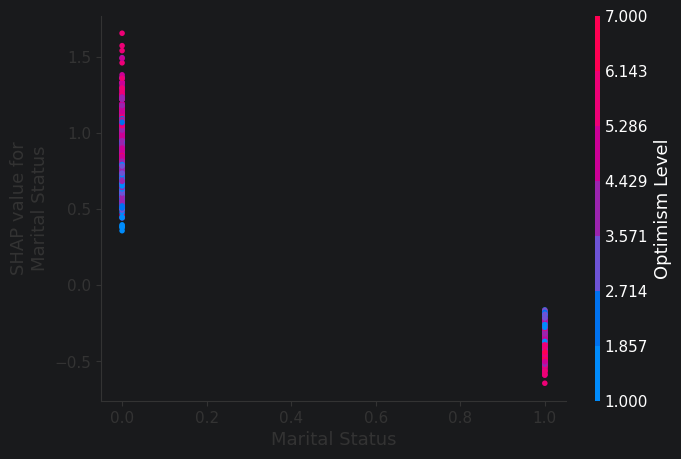

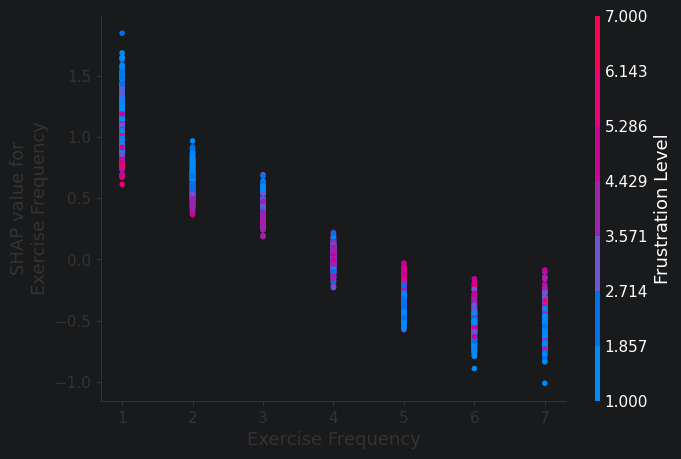

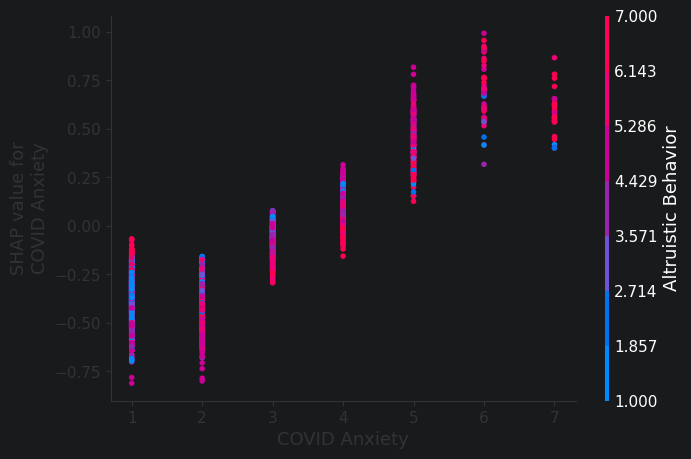

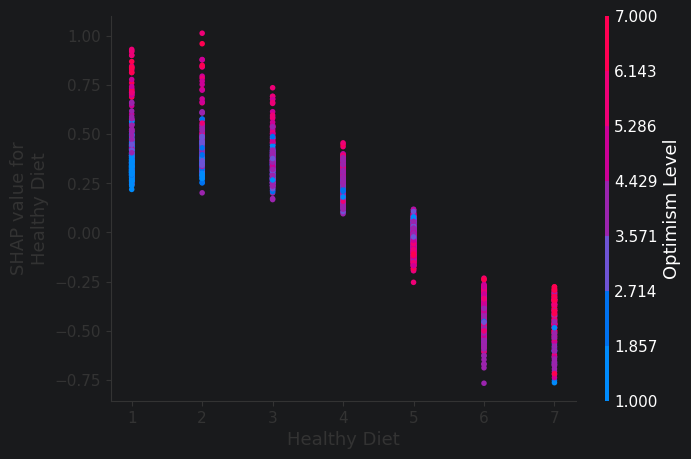

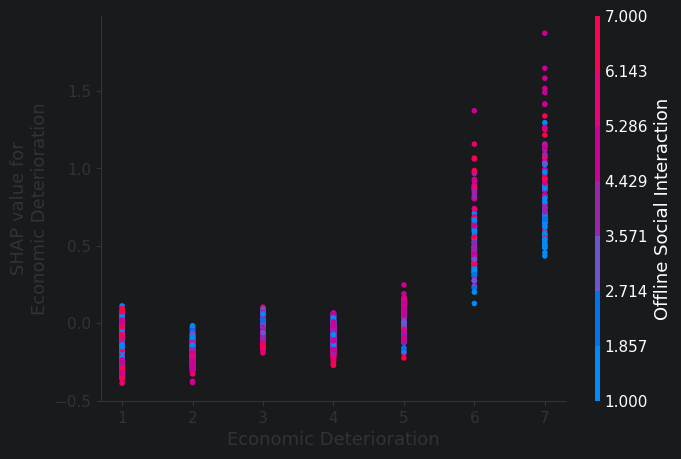

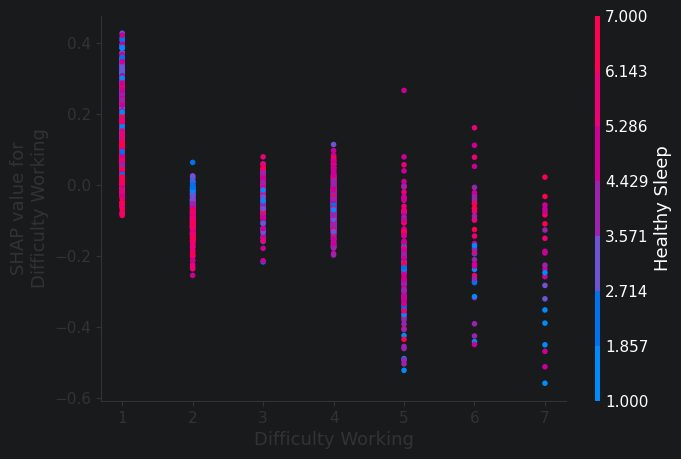

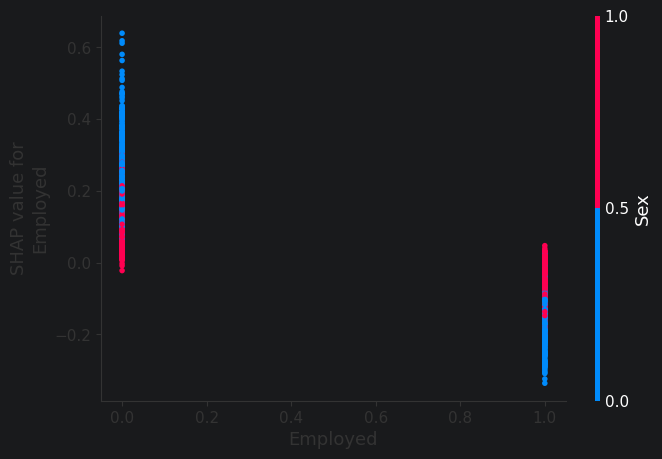

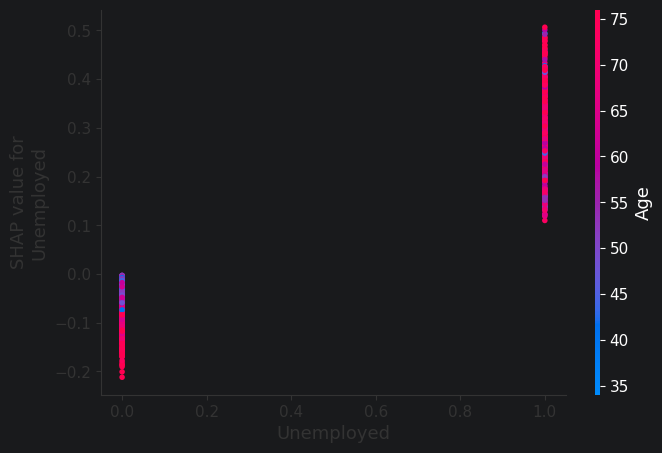

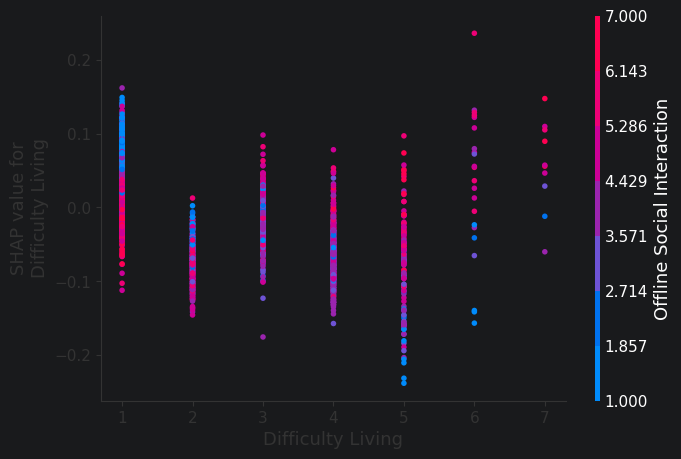

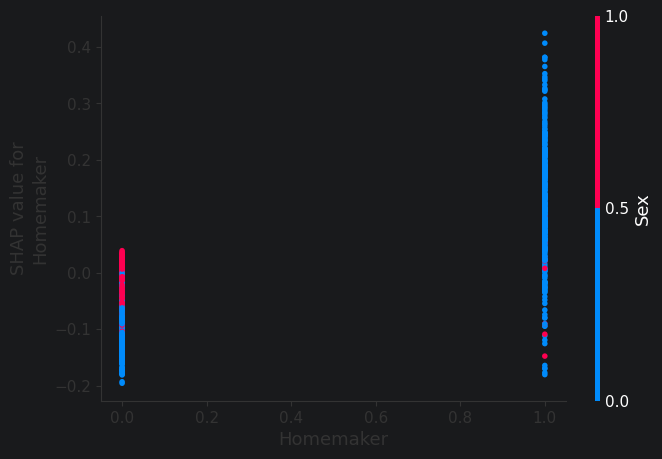

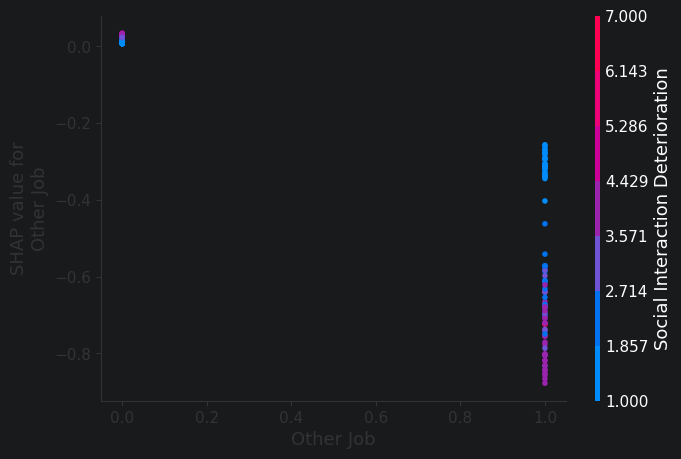

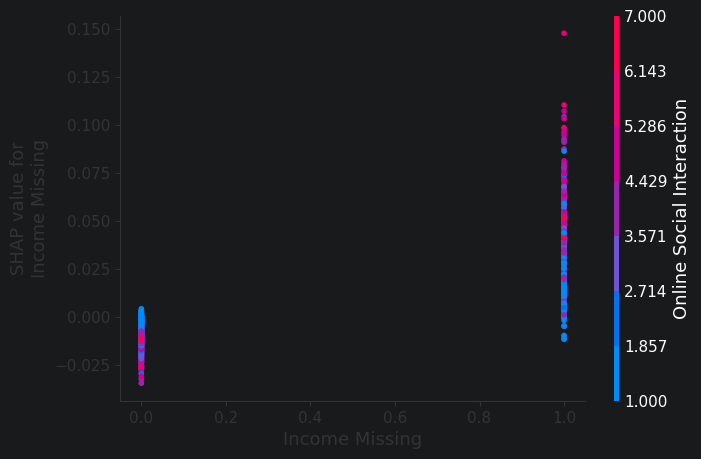

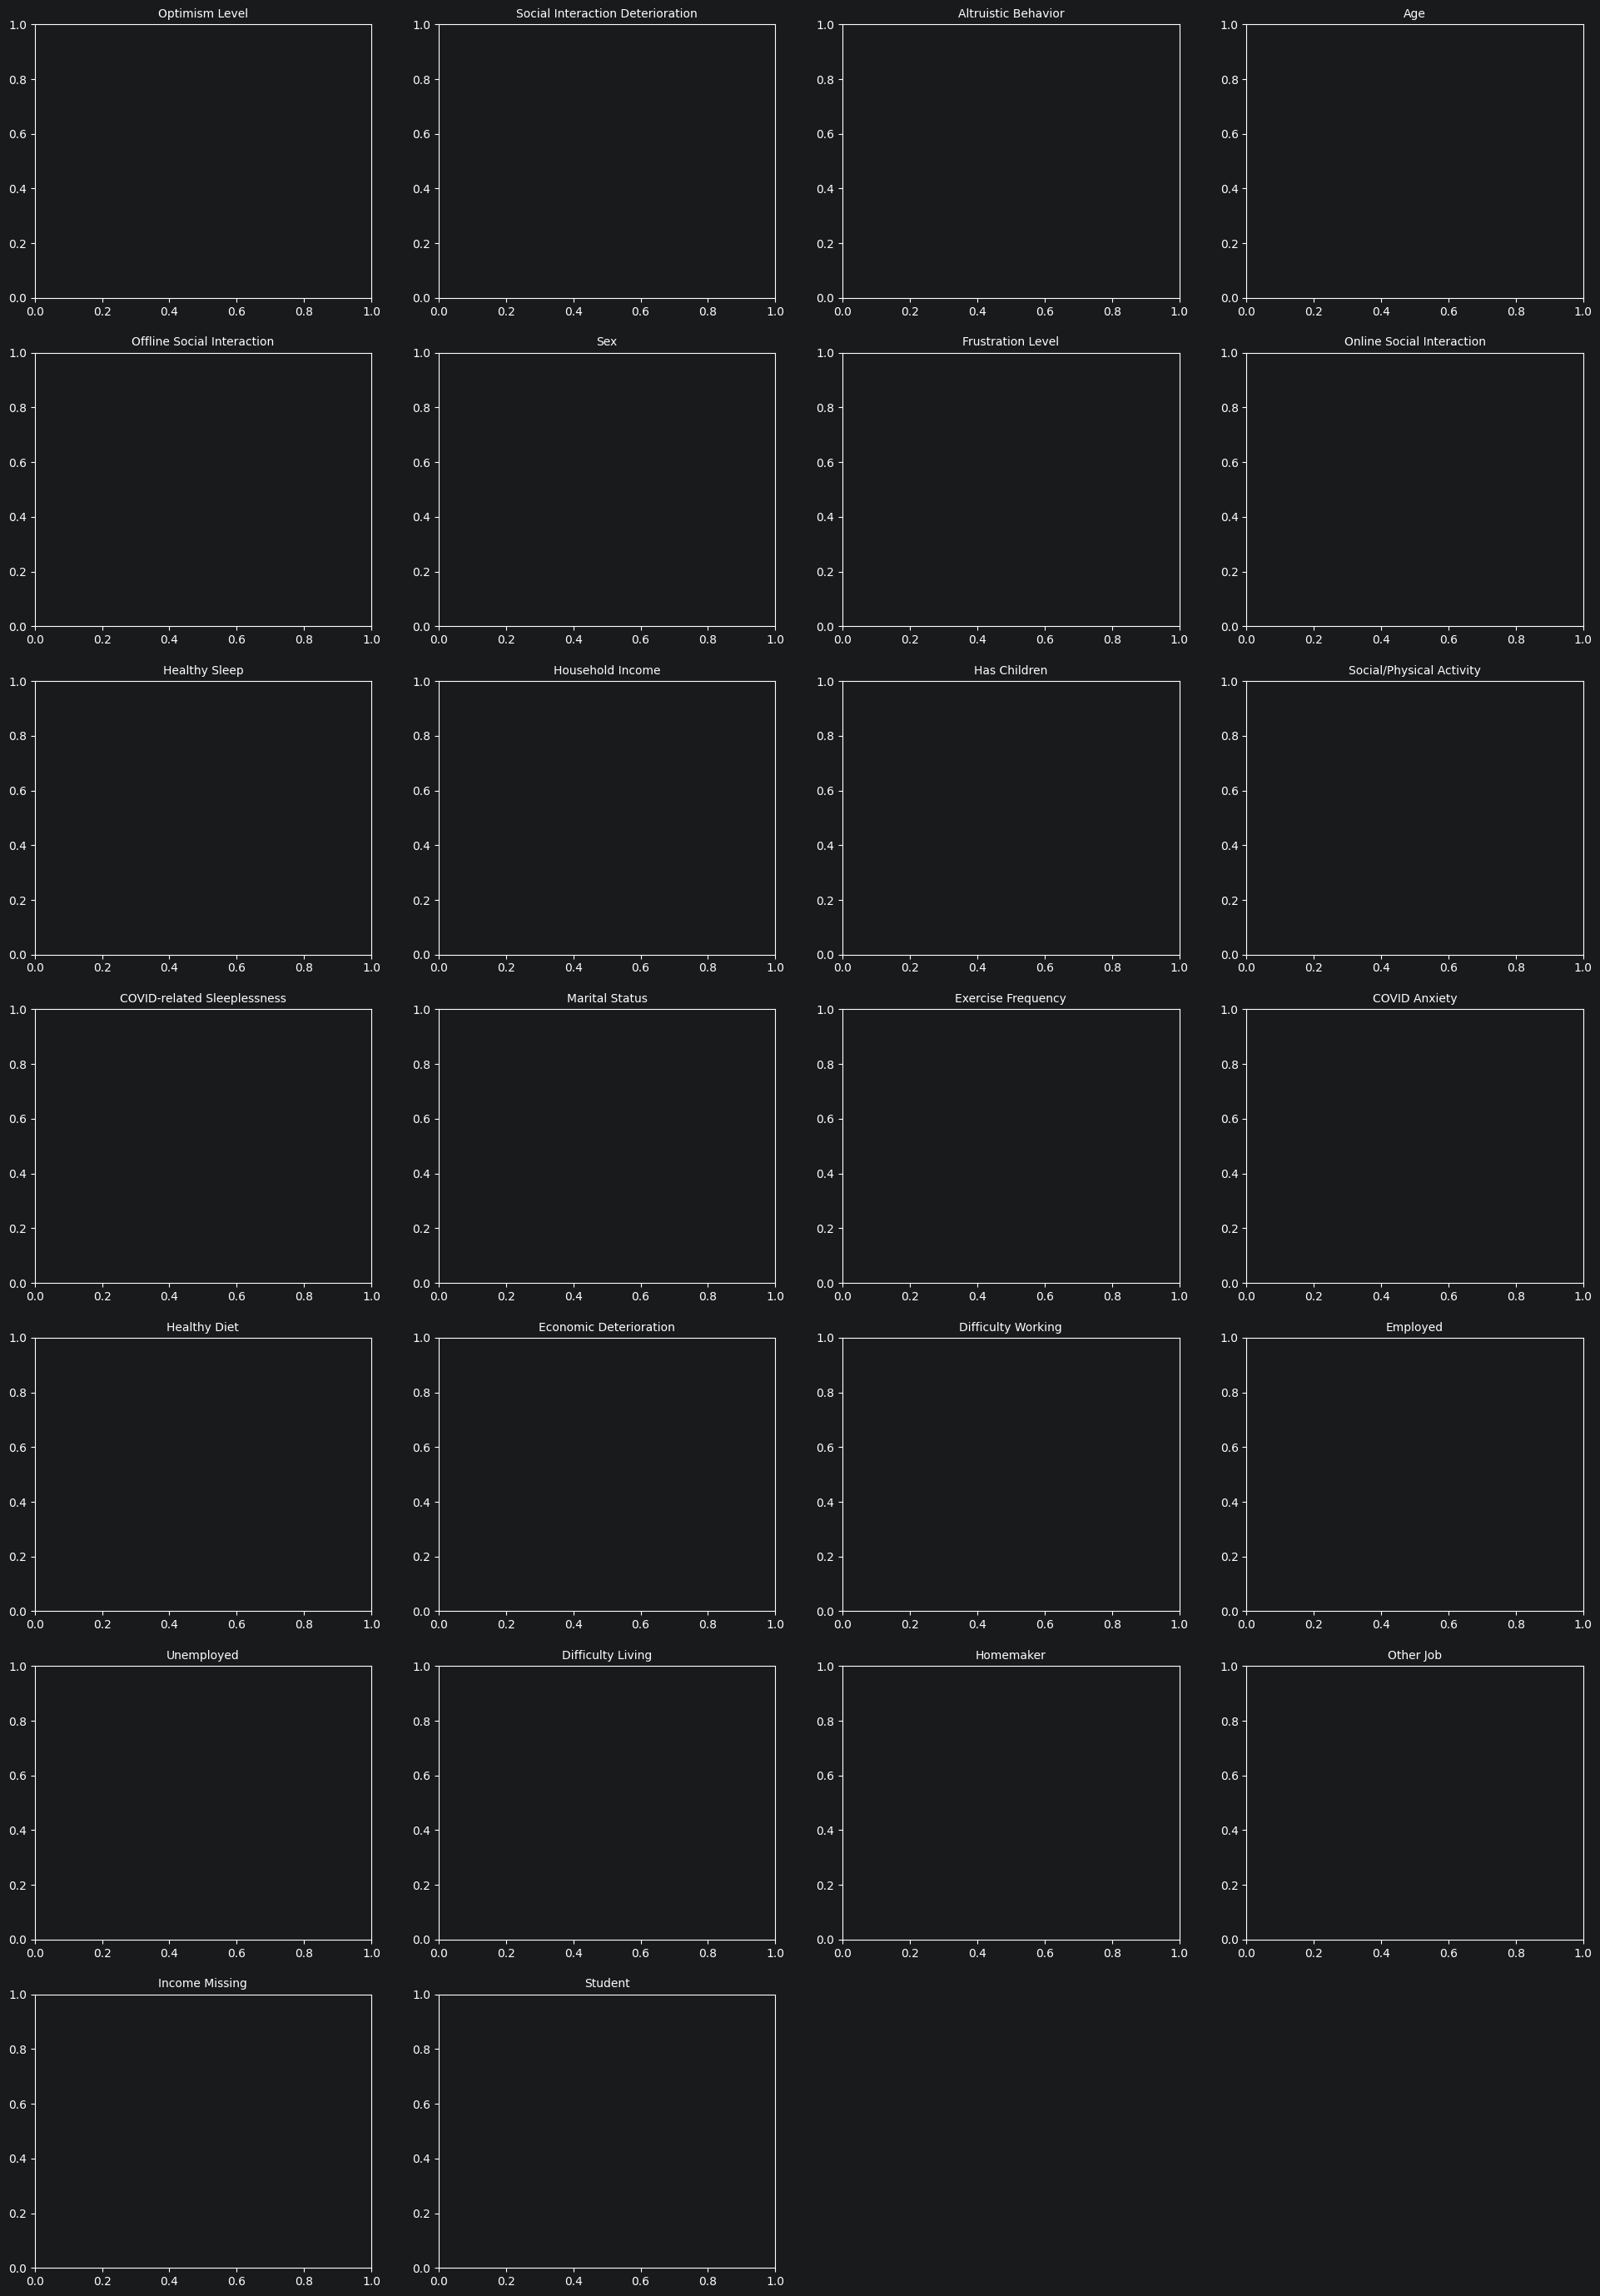

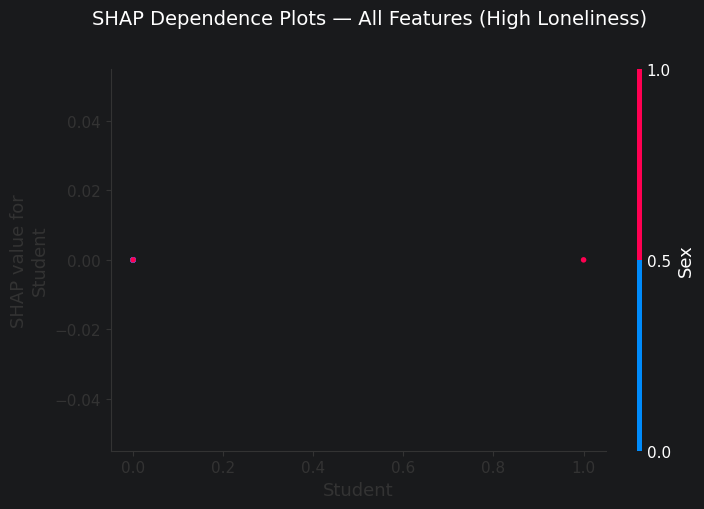

Saved: plots/shap/dependence_all_features.png


In [32]:
# Dependence plots for ALL features (High Loneliness class)
mean_abs_shap = np.abs(shap_values[1]).mean(axis=0)
sorted_indices = np.argsort(mean_abs_shap)[::-1]

print(f"All {n_features} features by mean |SHAP| (High Loneliness):")
for rank, idx in enumerate(sorted_indices, 1):
    print(f"  {rank}. {display_names_list[idx]} = {mean_abs_shap[idx]:.4f}")

# Plot in a grid
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for plot_idx, feat_idx in enumerate(sorted_indices):
    plt.sca(axes[plot_idx])
    shap.dependence_plot(feat_idx, shap_values[1], X_explain,
                         feature_names=display_names_list,
                         interaction_index="auto", show=False)
    axes[plot_idx].set_title(display_names_list[feat_idx], fontsize=10)

# Hide empty subplots
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("SHAP Dependence Plots — All Features (High Loneliness)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("plots/shap/dependence_all_features.png", dpi=150, bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print("Saved: plots/shap/dependence_all_features.png")


Sample 0: Predicted = High Loneliness
  P(Low)  = 0.143
  P(High) = 0.857


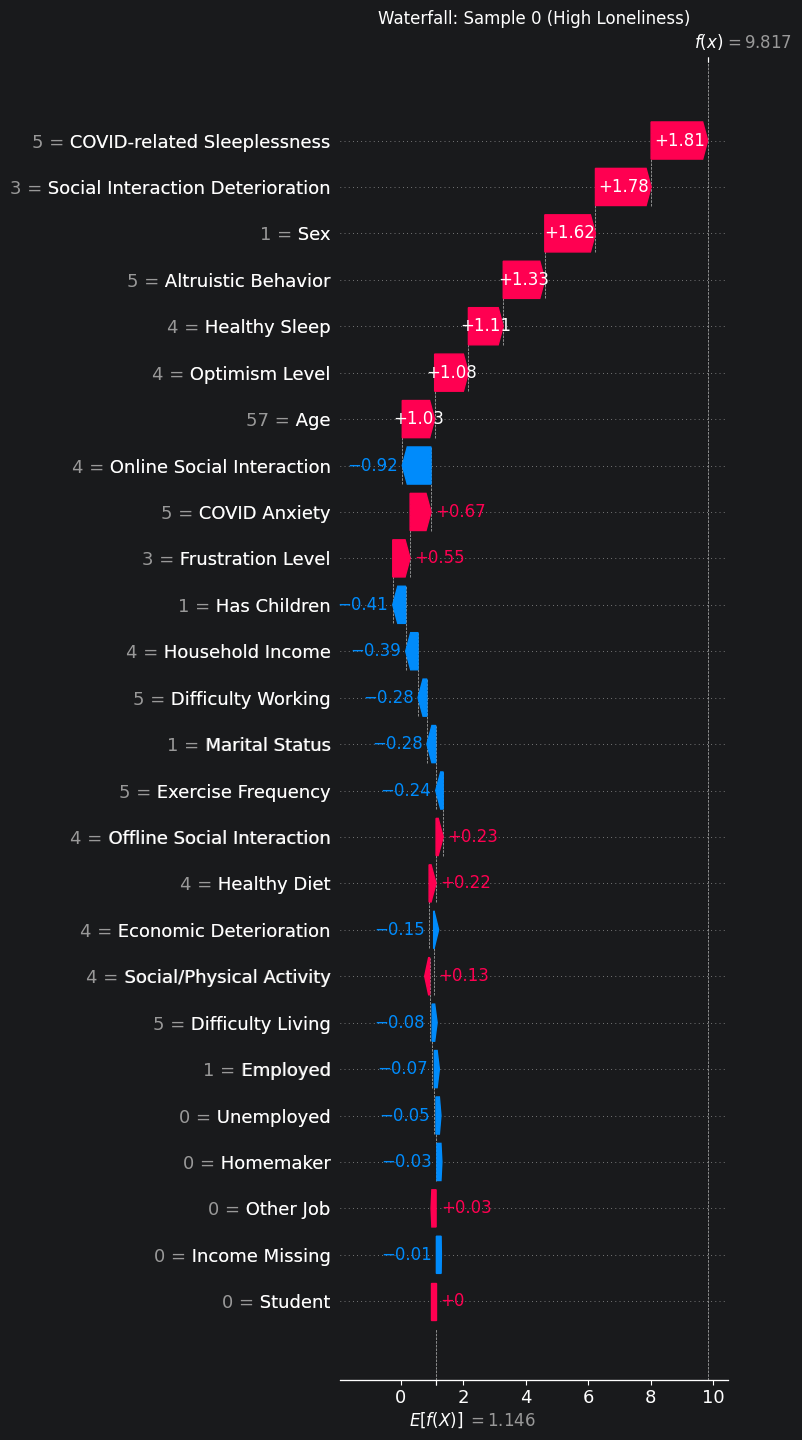

Saved: plots/shap/waterfall_sample_0.png


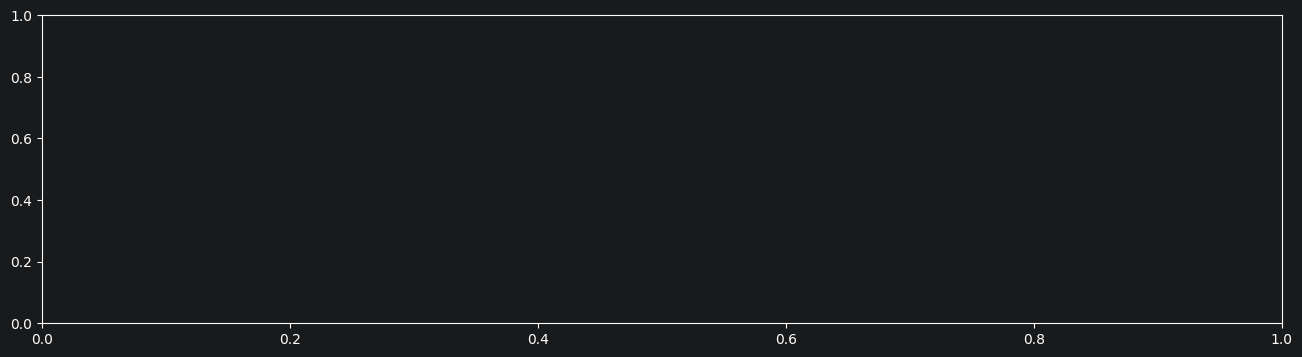

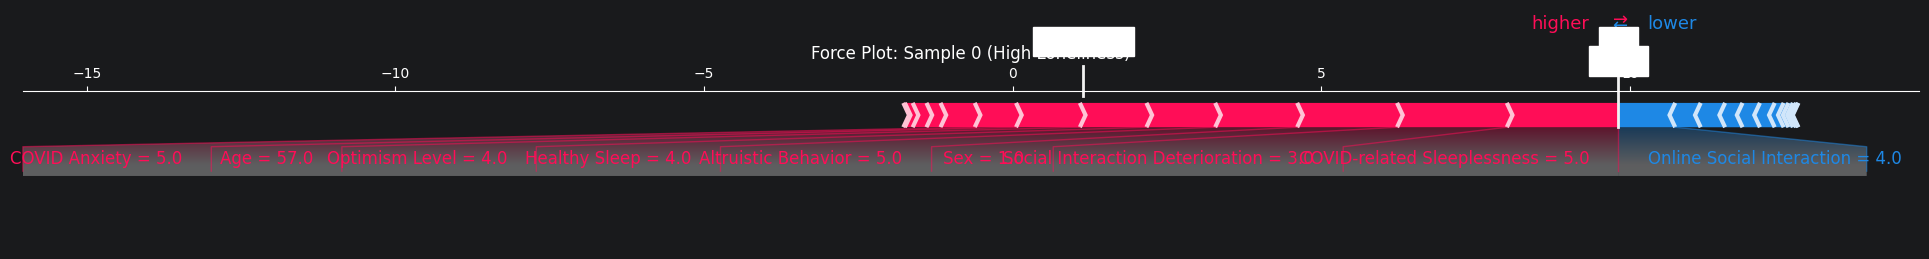

Saved: plots/shap/force_sample_0.png


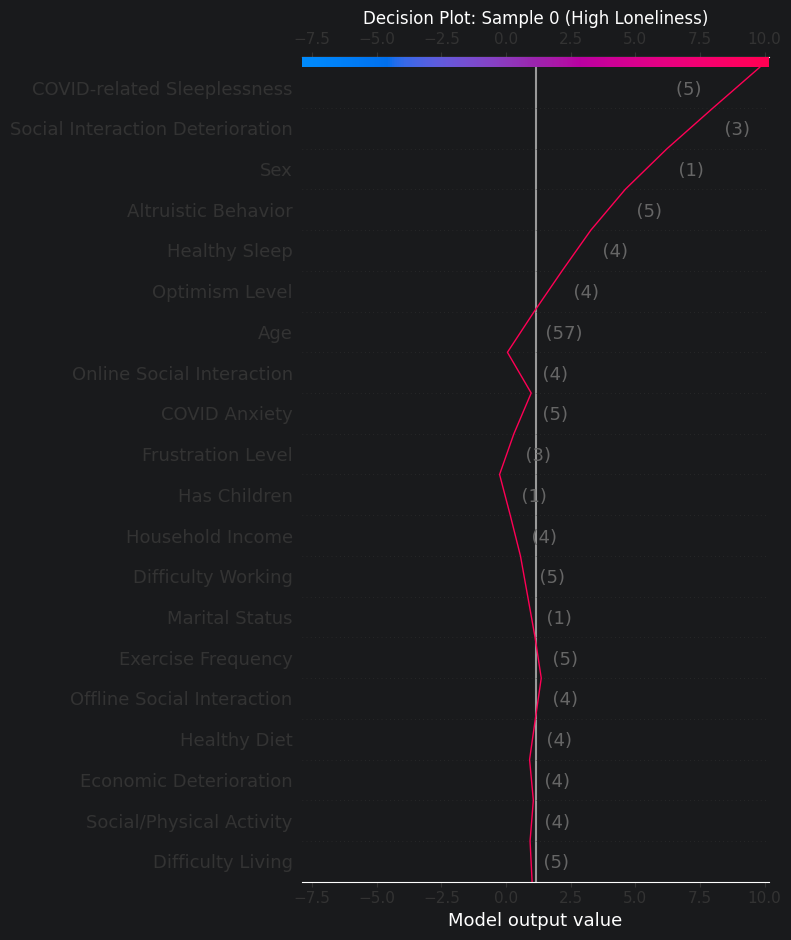

Saved: plots/shap/decision_sample_0.png


In [33]:
# --- Individual sample explanations ---
# Waterfall, force, and decision plots for a single sample.

sample_idx = 0                # <-- change to inspect a different sample
class_idx = 1                 # 0 = Low Loneliness, 1 = High Loneliness

pred = model.predict(X_explain.iloc[[sample_idx]])[0]
prob = model.predict_proba(X_explain.iloc[[sample_idx]])[0]
print(f"Sample {sample_idx}: Predicted = {class_names[pred]}")
print(f"  P(Low)  = {prob[0]:.3f}")
print(f"  P(High) = {prob[1]:.3f}")

# Handle expected_value: scalar (binary LGBMClassifier) or array
ev = shap_explainer.expected_value
if np.isscalar(ev) or (isinstance(ev, np.ndarray) and ev.ndim == 0):
    base_values = [float(-ev), float(ev)]
else:
    base_values = [float(ev[0]), float(ev[1])]

# ---- Waterfall plot ----
shap_explanation = shap.Explanation(
    values=shap_values[class_idx][sample_idx],
    base_values=base_values[class_idx],
    data=X_explain.iloc[sample_idx].values,
    feature_names=display_names_list
)

fig, ax = plt.subplots(figsize=(10, max(7, n_features * 0.3)))
shap.waterfall_plot(shap_explanation, show=False, max_display=n_features)
plt.title(f"Waterfall: Sample {sample_idx} ({class_names[class_idx]})")
plt.tight_layout()
plt.savefig(f"plots/shap/waterfall_sample_{sample_idx}.png", dpi=150, bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print(f"Saved: plots/shap/waterfall_sample_{sample_idx}.png")

# ---- Force plot ----
shap.initjs()
fig, ax = plt.subplots(figsize=(16, 4))
shap.force_plot(base_values[class_idx],
                shap_values[class_idx][sample_idx, :],
                X_explain.iloc[sample_idx, :],
                feature_names=display_names_list,
                matplotlib=True, show=False)
plt.title(f"Force Plot: Sample {sample_idx} ({class_names[class_idx]})")
plt.tight_layout()
plt.savefig(f"plots/shap/force_sample_{sample_idx}.png", dpi=150, bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print(f"Saved: plots/shap/force_sample_{sample_idx}.png")

# ---- Decision plot ----
fig, ax = plt.subplots(figsize=(10, 8))
shap.decision_plot(base_values[class_idx],
                   shap_values[class_idx][sample_idx, :],
                   X_explain.iloc[sample_idx, :],
                   feature_names=display_names_list,
                   show=False)
plt.title(f"Decision Plot: Sample {sample_idx} ({class_names[class_idx]})")
plt.tight_layout()
plt.savefig(f"plots/shap/decision_sample_{sample_idx}.png", dpi=150, bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print(f"Saved: plots/shap/decision_sample_{sample_idx}.png")


# Counterfactual Explanations

https://interpret.ml/DiCE/notebooks/DiCE_model_agnostic_CFs.html

In [34]:
# Prepare DiceML data object
df_dice_train = X_train.copy()
df_dice_train[target_UCLA] = y_train.values

continuous_features = features_UCLA.copy()

permitted_range = {} # Binary features clamped to [0, 1]
binary_features = ["Sex_Male", "Is_Married", "Has_Child", "Income_Missing",
                   "Job_Employed", "Job_Homemaker", "Job_Student",
                   "Job_Unemployed", "Job_Other"]
for feat in features_UCLA:
    if feat in binary_features:
        permitted_range[feat] = [0, 1]
    else:
        permitted_range[feat] = [float(X_train[feat].min()),
                                 float(X_train[feat].max())]

dice_data = dice_ml.Data(
    dataframe=df_dice_train,
    continuous_features=continuous_features,
    outcome_name=target_UCLA
)

dice_model = dice_ml.Model(model=model, backend="sklearn")

# Three explainers — one per generation strategy.
# - random  : perturbs the original instance; CFs are SYNTHETIC.
# - kdtree  : returns nearest-neighbor TRAINING ROWS of the desired class.
# - genetic : evolves a population to find low-cost CFs.
dice_exp         = dice_ml.Dice(dice_data, dice_model, method="random")
dice_exp_kdtree  = dice_ml.Dice(dice_data, dice_model, method="kdtree")
dice_exp_genetic = dice_ml.Dice(dice_data, dice_model, method="genetic")

print("DiceML explainers initialized: random, kdtree, genetic.")
print(f"Continuous features: {len(continuous_features)}")
print(f"Permitted ranges defined for {len(permitted_range)} features.")

DiceML explainers initialized: random, kdtree, genetic.
Continuous features: 26
Permitted ranges defined for 26 features.


In [35]:
# Single-sample counterfactual
sample_idx = 0 # <-- change to inspect a different sample
test_instance = X_test.iloc[[sample_idx]]

pred = model.predict(test_instance)[0]
prob = model.predict_proba(test_instance)[0]

print(f"Original prediction: {class_names[pred]}")
print(f"Probabilities: Low={prob[0]:.3f}, High={prob[1]:.3f}")
print(f"\nFeature values (with category labels):")
for feat in features_UCLA:
    val = test_instance.iloc[0][feat]
    print(f"  {get_display_name(feat)}: {format_feature_value(feat, val)}")

Original prediction: High Loneliness
Probabilities: Low=0.143, High=0.857

Feature values (with category labels):
  Sex: Male
  Age: 57 years
  Marital Status: Married
  Has Children: Has Children
  Household Income: 6.0-7.9M JPY
  Income Missing: Income Reported
  Employed: Employed
  Homemaker: Not Homemaker
  Student: Not Student
  Unemployed: Not Unemployed
  Other Job: Not Other Job
  Social/Physical Activity: 4.0/7
  Exercise Frequency: 5.0/7
  Healthy Diet: 4.0/7
  Healthy Sleep: 4.0/7
  Offline Social Interaction: 4.0/7
  Online Social Interaction: 4.0/7
  Altruistic Behavior: 5.0/7
  Frustration Level: 3.0/7
  Optimism Level: 4.0/7
  COVID Anxiety: 5.0/7
  COVID-related Sleeplessness: 5.0/7
  Economic Deterioration: 4.0/7
  Social Interaction Deterioration: 3.0/7
  Difficulty Living: 5.0/7
  Difficulty Working: 5.0/7


In [36]:
# Generate counterfactuals
print(f"Generating {N_CF_PER_SAMPLE} counterfactuals...")
start_time = time.time()

dice_result = dice_exp.generate_counterfactuals(
    test_instance,
    total_CFs=N_CF_PER_SAMPLE,
    desired_class="opposite",
    permitted_range=permitted_range,
    random_seed=random_state
)

print(f"Generated in {format_time(time.time() - start_time)}")

Generating 5 counterfactuals...


100%|██████████| 1/1 [01:43<00:00, 103.66s/it]

Generated in 1m 43.66s


In [37]:
# Display with category labels
cf_df = dice_result.cf_examples_list[0].final_cfs_df
if cf_df is not None and len(cf_df) > 0:
    print(f"\n=== Counterfactual Changes (with labels) ===")
    original = test_instance.iloc[0]
    for cf_idx, (_, cf_row) in enumerate(cf_df.iterrows()):
        print(f"\nCounterfactual {cf_idx + 1}:")
        for feat in features_UCLA:
            orig_val = original[feat]
            cf_val = cf_row[feat]
            if abs(cf_val - orig_val) > 0.01:
                orig_label = format_feature_value(feat, orig_val)
                cf_label = format_feature_value(feat, cf_val)
                direction = "↑" if cf_val > orig_val else "↓"
                print(f"  {get_display_name(feat)}: {orig_label} → {cf_label} ({direction} {abs(cf_val - orig_val):.2f})")


=== Counterfactual Changes (with labels) ===

Counterfactual 1:
  Sex: Male → Female (↓ 1.00)
  COVID-related Sleeplessness: 5.0/7 → 2.0/7 (↓ 3.00)
  Social Interaction Deterioration: 3.0/7 → 2.0/7 (↓ 1.00)

Counterfactual 2:
  Age: 57 years → 83 years (↑ 26.00)
  Offline Social Interaction: 4.0/7 → 7.0/7 (↑ 3.00)

Counterfactual 3:
  Sex: Male → Female (↓ 1.00)
  Age: 57 years → 88 years (↑ 31.00)
  Social/Physical Activity: 4.0/7 → 6.0/7 (↑ 2.00)

Counterfactual 4:
  Age: 57 years → 88 years (↑ 31.00)
  Homemaker: Not Homemaker → Homemaker (↑ 1.00)
  Social Interaction Deterioration: 3.0/7 → 2.0/7 (↓ 1.00)

Counterfactual 5:
  Age: 57 years → 69 years (↑ 12.00)
  Other Job: Not Other Job → Other Job (↑ 1.00)
  Frustration Level: 3.0/7 → 1.0/7 (↓ 2.00)
  Social Interaction Deterioration: 3.0/7 → 1.0/7 (↓ 2.00)


In [38]:
# Save single-sample CF plot
fig, ax = plt.subplots(figsize=(12, 6))
if cf_df is not None and len(cf_df) > 0:
    changes_data = []
    for feat in features_UCLA:
        orig_val = original[feat]
        for cf_idx, (_, cf_row) in enumerate(cf_df.iterrows()):
            cf_val = cf_row[feat]
            if abs(cf_val - orig_val) > 0.01:
                changes_data.append({
                    "Feature": get_display_name(feat),
                    "CF": f"CF {cf_idx+1}",
                    "Change": cf_val - orig_val
                })
    if changes_data:
        changes_plot_df = pd.DataFrame(changes_data)
        fig = px.bar(changes_plot_df, x="Change", y="Feature", color="CF",
                     orientation="h", barmode="group",
                     title=f"Counterfactual Changes for Sample {sample_idx}")
        fig.update_layout(height=max(400, len(changes_plot_df["Feature"].unique()) * 30))
        fig.write_image(f"plots/counterfactuals/cf_sample_{sample_idx}.png", scale=2)
        fig.show()
        print(f"Saved: plots/counterfactuals/cf_sample_{sample_idx}.png")

Saved: plots/counterfactuals/cf_sample_0.png


## Shared Sample Indices for All Counterfactual Runs

### Stratified sampling
https://stackoverflow.com/questions/50195187/how-to-do-a-random-stratified-sampling-with-python-not-a-train-test-split

In [39]:
# Shared list of test-set sample indices used by every CFX experiment.
# Same samples makes things directly comparable across runs.
# Stratified sampling in order to represent a wider range of ages

# Reset position so X_test.iloc[idx] is unambiguous downstream.
_xtest_pos = X_test.reset_index(drop=True)

if N_CF_SAMPLES is None:
    CF_SAMPLE_INDICES = list(range(len(_xtest_pos)))
    print(f"CF run: ALL {len(CF_SAMPLE_INDICES)} test samples.")
else:
    rng = np.random.RandomState(random_state)
    age_tertiles = pd.qcut(_xtest_pos["Age"], q=3,
                           labels=["young", "mid", "senior"])
    strata = (_xtest_pos["Sex_Male"].astype(int).astype(str)
              + "_" + age_tertiles.astype(str))

    unique_strata = sorted(strata.unique())
    n_strata = len(unique_strata)
    base = N_CF_SAMPLES // n_strata
    extra = N_CF_SAMPLES - base * n_strata

    selected = []
    for k, stratum in enumerate(unique_strata):
        pool = np.where(strata.values == stratum)[0]
        n_take = min(base + (1 if k < extra else 0), len(pool))
        chosen = rng.choice(pool, size=n_take, replace=False)
        selected.extend(chosen.tolist())

    CF_SAMPLE_INDICES = sorted(int(i) for i in selected)

    sample = _xtest_pos.iloc[CF_SAMPLE_INDICES]
    sex_label = sample["Sex_Male"].map({0: "Female", 1: "Male"})
    age_bin = age_tertiles.iloc[CF_SAMPLE_INDICES]

    print(f"CF run: stratified sample of {len(CF_SAMPLE_INDICES)} test samples "
          f"({n_strata} strata, ~{base} each).")
    print("\nSex breakdown:")
    print(sex_label.value_counts().to_string())
    print("\nAge tertile breakdown:")
    print(age_bin.value_counts().to_string())
    print("\nSex × Age tertile:")
    print(pd.crosstab(sex_label, age_bin).to_string())
    print("\nAge summary stats:")
    print(sample["Age"].describe().round(1).to_string())

print("\nIndices are reused across the unrestricted and restricted runs.")


CF run: stratified sample of 60 test samples (6 strata, ~10 each).

Sex breakdown:
Sex_Male
Male      30
Female    30

Age tertile breakdown:
Age
young     20
mid       20
senior    20

Sex × Age tertile:
Age       young  mid  senior
Sex_Male                    
Female       10   10      10
Male         10   10      10

Age summary stats:
count    60.0
mean     55.7
std      12.9
min      29.0
25%      46.0
50%      57.0
75%      64.2
max      79.0

Indices are reused across the unrestricted and restricted runs.


In [40]:
# Helpers
def _generate_batch_cfs(explainer, indices, *, total_cfs, perm_range,
                        features_to_vary=None, label="CFs",
                        record_source_train=False):
    """Generate counterfactuals for `indices`. Returns (results, summary)."""
    if record_source_train:
        # Vectorized exact-match against training data for kdtree CFs.
        _x_train_pos = X_train.reset_index(drop=True)
        _x_train_arr = _x_train_pos[features_UCLA].values
    else:
        _x_train_arr = None

    results = []
    n_valid = 0
    sparsities, proximities = [], []
    t0 = time.time()

    for idx in indices:
        instance = X_test.iloc[[idx]]
        original_pred = int(model.predict(instance)[0])
        original_values = instance.iloc[0].to_dict()
        cfs = []
        try:
            kwargs = dict(total_CFs=total_cfs,
                          desired_class="opposite",
                          permitted_range=perm_range)
            # Only DiceRandom accepts random_seed; DiceKD and DiceGenetic raise TypeError if we pass it urkkkkk
            if type(explainer).__name__ == "DiceRandom":
                kwargs["random_seed"] = random_state
            if features_to_vary is not None:
                kwargs["features_to_vary"] = features_to_vary
            cf = explainer.generate_counterfactuals(instance, **kwargs)
            cf_df_local = cf.cf_examples_list[0].final_cfs_df
            if cf_df_local is not None and len(cf_df_local) > 0:
                for cf_dict in cf_df_local.to_dict("records"):
                    cf_dict["basis_idx"] = int(idx)
                    if record_source_train:
                        cf_arr = np.array(
                            [cf_dict[f] for f in features_UCLA],
                            dtype=float,
                        )
                        # exact match (kdtree returns real training rows)
                        matches = np.where(
                            np.all(np.isclose(_x_train_arr, cf_arr,
                                               rtol=0, atol=1e-6), axis=1)
                        )[0]
                        cf_dict["source_train_idx"] = (
                            int(matches[0]) if len(matches) > 0 else None
                        )
                    cfs.append(cf_dict)
                    diffs = [abs(cf_dict[f] - original_values[f])
                             for f in features_UCLA]
                    sparsities.append(sum(1 for d in diffs if d > 0.01))
                    proximities.append(sum(diffs))
                n_valid += 1
        except Exception as exc:
            print(f"  Sample {idx}: error — {exc}")

        results.append({
            "sample_idx": int(idx),
            "basis_idx": int(idx),
            "original_pred": original_pred,
            "original_values": original_values,
            "counterfactuals": cfs,
            "n_counterfactuals": len(cfs),
        })

    elapsed = time.time() - t0
    summary = {
        "label": label,
        "n_total": len(indices),
        "n_valid": n_valid,
        "validity": n_valid / len(indices) if indices else float("nan"),
        "avg_sparsity": float(np.mean(sparsities)) if sparsities else float("nan"),
        "avg_proximity": float(np.mean(proximities)) if proximities else float("nan"),
        "elapsed_s": elapsed,
    }
    print(f"  {label}: {n_valid}/{len(indices)} valid CF sets "
          f"in {format_time(elapsed)}")
    return results, summary


def _save_cf_artifacts(cf_results, list_path, dict_path):
    """Persist both saved CF formats: list-of-dicts AND dict-by-sample."""
    with open(list_path, "wb") as f:
        pickle.dump(cf_results, f)
    precomputed = {r["sample_idx"]: r["counterfactuals"] for r in cf_results}
    with open(dict_path, "wb") as f:
        pickle.dump(precomputed, f)
    print(f"  Saved: {list_path}")
    print(f"  Saved: {dict_path}")


## Batch Counterfactuals


In [41]:
# Batch counterfactual generation (UNRESTRICTED) — or load from saved file
def _saved_indices_match(saved, expected):
    return [r["sample_idx"] for r in saved] == list(expected)

cf_results = None
if (
    LOAD_SAVED_CF
    and os.path.exists("explainers/dice_results.pkl")
):
    with open("explainers/dice_results.pkl", "rb") as f:
        cf_results = pickle.load(f)
    if _saved_indices_match(cf_results, CF_SAMPLE_INDICES):
        print(f"Loaded {len(cf_results)} saved CFs from explainers/dice_results.pkl")
    else:
        print("Saved CFs use different sample indices — regenerating.")
        cf_results = None

if cf_results is None:
    print(f"Generating UNRESTRICTED counterfactuals for "
          f"{len(CF_SAMPLE_INDICES)} samples ({N_CF_PER_SAMPLE} CFs each)...")
    cf_results, _summary_unr = _generate_batch_cfs(
        dice_exp, CF_SAMPLE_INDICES,
        total_cfs=N_CF_PER_SAMPLE,
        perm_range=permitted_range,
        label="Unrestricted",
    )
    # Inline save — right after generation
    _save_cf_artifacts(cf_results,
                       "explainers/dice_results.pkl",
                       "explainers/counterfactual_results.pkl")


Loaded 60 saved CFs from explainers/dice_results.pkl


## KDTree Counterfactuals (real training-set examples)


In [42]:
cf_results_kdtree = None
if (
    LOAD_SAVED_CF
    and os.path.exists("explainers/dice_results_kdtree.pkl")
):
    with open("explainers/dice_results_kdtree.pkl", "rb") as f:
        cf_results_kdtree = pickle.load(f)
    if _saved_indices_match(cf_results_kdtree, CF_SAMPLE_INDICES):
        print(f"Loaded {len(cf_results_kdtree)} saved kdtree CFs.")
    else:
        print("Saved kdtree CFs use different indices — regenerating.")
        cf_results_kdtree = None

if cf_results_kdtree is None:
    np.random.seed(random_state)  # reproducibility for non-seeded DiCE methods
    print(f"Generating KDTREE counterfactuals for "
          f"{len(CF_SAMPLE_INDICES)} samples ({N_CF_PER_SAMPLE} CFs each)...")
    cf_results_kdtree, _summary_kdtree = _generate_batch_cfs(
        dice_exp_kdtree, CF_SAMPLE_INDICES,
        total_cfs=N_CF_PER_SAMPLE,
        perm_range=permitted_range,
        label="KDTree",
        record_source_train=True,
    )
    _save_cf_artifacts(cf_results_kdtree,
                       "explainers/dice_results_kdtree.pkl",
                       "explainers/counterfactual_results_kdtree.pkl")

# Quick sanity: how many CFs successfully matched a training row?
n_with_src = sum(
    1 for r in cf_results_kdtree
    for cf in r["counterfactuals"]
    if cf.get("source_train_idx") is not None
)
n_total_cfs = sum(r["n_counterfactuals"] for r in cf_results_kdtree)
print(f"\nMatched {n_with_src}/{n_total_cfs} kdtree CFs to training rows.")


Loaded 60 saved kdtree CFs.

Matched 300/300 kdtree CFs to training rows.


## Genetic Counterfactuals

In [43]:
cf_results_genetic = None
if (
    LOAD_SAVED_CF
    and os.path.exists("explainers/dice_results_genetic.pkl")
):
    with open("explainers/dice_results_genetic.pkl", "rb") as f:
        cf_results_genetic = pickle.load(f)
    if _saved_indices_match(cf_results_genetic, CF_SAMPLE_INDICES):
        print(f"Loaded {len(cf_results_genetic)} saved genetic CFs.")
    else:
        print("Saved genetic CFs use different indices — regenerating.")
        cf_results_genetic = None

if cf_results_genetic is None:
    np.random.seed(random_state)  # reproducibility for non-seeded DiCE methods
    print(f"Generating GENETIC counterfactuals for "
          f"{len(CF_SAMPLE_INDICES)} samples ({N_CF_PER_SAMPLE} CFs each)...")
    cf_results_genetic, _summary_gen = _generate_batch_cfs(
        dice_exp_genetic, CF_SAMPLE_INDICES,
        total_cfs=N_CF_PER_SAMPLE,
        perm_range=permitted_range,
        label="Genetic",
    )
    _save_cf_artifacts(cf_results_genetic,
                       "explainers/dice_results_genetic.pkl",
                       "explainers/counterfactual_results_genetic.pkl")


Loaded 60 saved genetic CFs.


## KDTree vs Random vs Genetic

In [44]:
# Aggregate metrics per method
def _summarize_cfs(cf_results, label):
    n_samples = len(cf_results)
    n_with_valid = sum(1 for r in cf_results if r["n_counterfactuals"] > 0)
    sparsities, proximities, diversities = [], [], []
    n_total_cfs = 0

    for r in cf_results:
        cfs = r["counterfactuals"]
        if not cfs:
            continue
        n_total_cfs += len(cfs)
        original_vals = r["original_values"]
        for cf in cfs:
            diffs = [abs(cf[f] - original_vals[f]) for f in features_UCLA]
            sparsities.append(sum(1 for d in diffs if d > 0.01))
            proximities.append(sum(diffs))
        # Pairwise diversity within this sample
        if len(cfs) > 1:
            pairs = []
            for i in range(len(cfs)):
                for j in range(i + 1, len(cfs)):
                    pairs.append(sum(
                        abs(cfs[i][f] - cfs[j][f]) for f in features_UCLA
                    ))
            diversities.append(float(np.mean(pairs)))

    return {
        "Method": label,
        "Validity": n_with_valid / n_samples if n_samples else float("nan"),
        "Total CFs": n_total_cfs,
        "Avg CFs / valid sample": (n_total_cfs / n_with_valid) if n_with_valid else float("nan"),
        "Avg Sparsity": float(np.mean(sparsities)) if sparsities else float("nan"),
        "Avg Proximity": float(np.mean(proximities)) if proximities else float("nan"),
        "Avg Diversity": float(np.mean(diversities)) if diversities else float("nan"),
        "Plausibility": ("real training rows" if label == "KDTree" else "synthesized"),
    }

method_summaries = []
if cf_results is not None:
    method_summaries.append(_summarize_cfs(cf_results, "Random"))
if cf_results_kdtree is not None:
    method_summaries.append(_summarize_cfs(cf_results_kdtree, "KDTree"))
if cf_results_genetic is not None:
    method_summaries.append(_summarize_cfs(cf_results_genetic, "Genetic"))

df_method_compare = pd.DataFrame(method_summaries).set_index("Method")
print("=== Aggregate metrics per method ===")
display(df_method_compare.round(3))

# Persist alongside the per-method CF artifacts
os.makedirs("explainers/cfx_methods", exist_ok=True)
df_method_compare.to_csv("explainers/cfx_methods/method_comparison.csv")
print("\nSaved: explainers/cfx_methods/method_comparison.csv")


=== Aggregate metrics per method ===


,Validity,Total CFs,Avg CFs / valid sample,Avg Sparsity,Avg Proximity,Avg Diversity,Plausibility
Method,,,,,,,
Random,1.0,300,5.00,3.383,25.723,22.117,synthesized
KDTree,1.0,300,5.00,11.737,20.180,19.513,real training rows
Genetic,1.0,297,4.95,10.279,24.939,24.931,synthesized



Saved: explainers/cfx_methods/method_comparison.csv


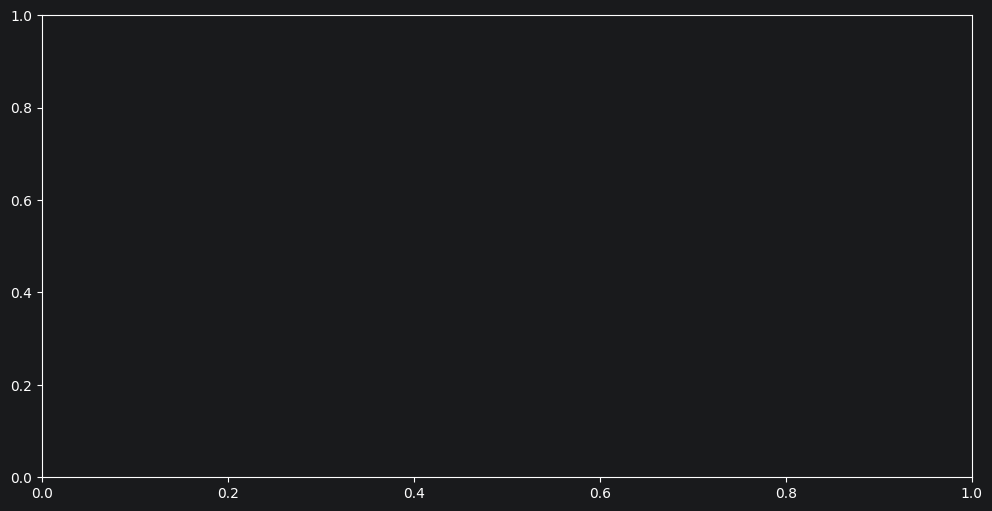

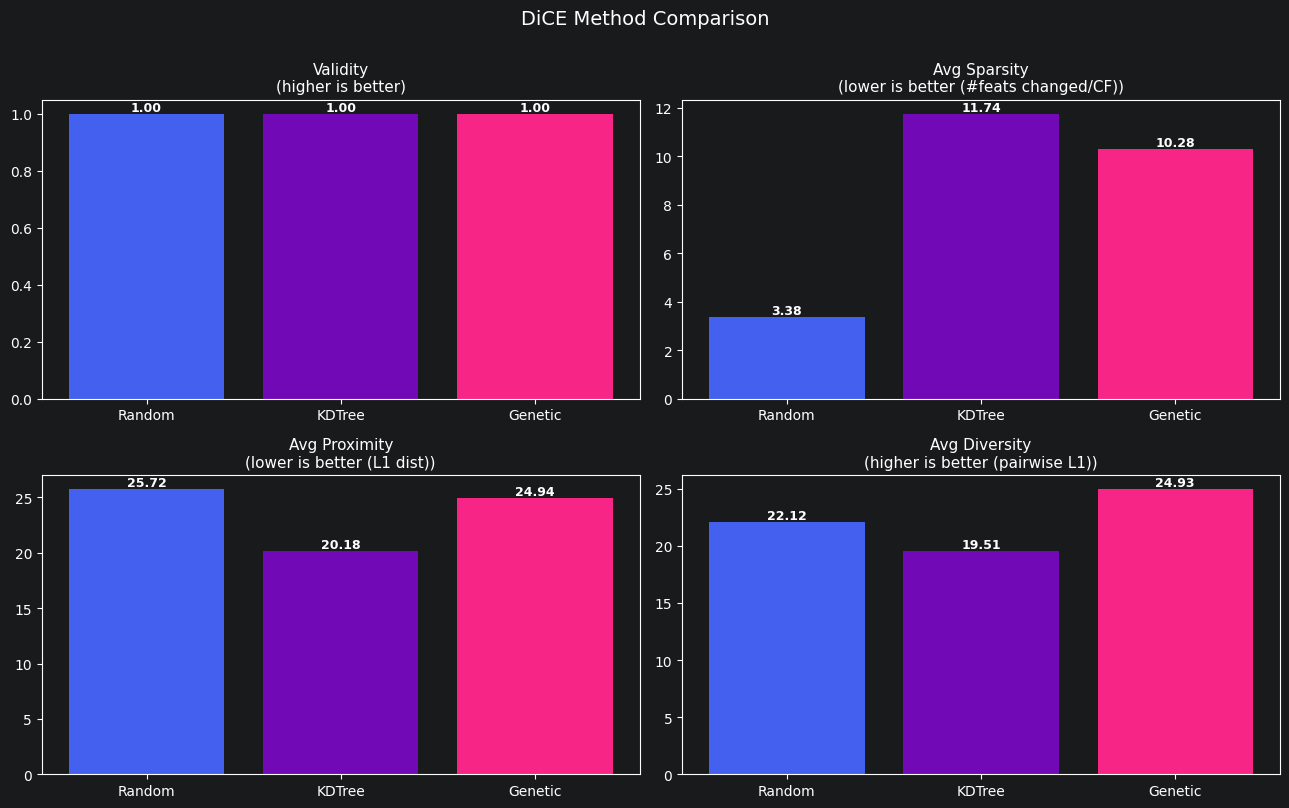

Saved: plots/cfx_method_comparison_metrics.png


In [45]:
# Bar chart: side-by-side comparison on the four numeric metrics
metrics = [
    ("Validity", "higher is better"),
    ("Avg Sparsity", "lower is better (#feats changed/CF)"),
    ("Avg Proximity", "lower is better (L1 dist)"),
    ("Avg Diversity", "higher is better (pairwise L1)"),
]
method_colors = {"Random": "#4361ee", "KDTree": "#7209b7", "Genetic": "#f72585"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (metric, hint) in zip(axes.flatten(), metrics):
    vals = df_method_compare[metric]
    bars = ax.bar(vals.index, vals.values,
                  color=[method_colors.get(m, "steelblue") for m in vals.index])
    ax.set_title(f"{metric}\n({hint})", fontsize=11)
    ax.set_xlabel("")
    for i, v in enumerate(vals.values):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom",
                fontweight="bold", fontsize=9)

plt.suptitle("DiCE Method Comparison", fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig("plots/cfx_method_comparison_metrics.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: plots/cfx_method_comparison_metrics.png")


In [46]:
# Per-feature change frequency: which features each method tends to touch
def _feature_change_counts(cf_results):
    counts = {f: 0 for f in features_UCLA}
    for r in cf_results:
        original_vals = r["original_values"]
        for cf in r["counterfactuals"]:
            for f in features_UCLA:
                if abs(cf[f] - original_vals[f]) > 0.01:
                    counts[f] += 1
    return counts

method_feat_counts = {}
if cf_results is not None:
    method_feat_counts["Random"] = _feature_change_counts(cf_results)
if cf_results_kdtree is not None:
    method_feat_counts["KDTree"] = _feature_change_counts(cf_results_kdtree)
if cf_results_genetic is not None:
    method_feat_counts["Genetic"] = _feature_change_counts(cf_results_genetic)

feat_count_df = pd.DataFrame(method_feat_counts)
feat_count_df["Display Name"] = [
    FEATURE_DISPLAY_NAMES.get(f, f) for f in feat_count_df.index
]
method_cols = [c for c in feat_count_df.columns if c != "Display Name"]
feat_count_df = feat_count_df.sort_values(method_cols[0], ascending=True)

melted = feat_count_df.reset_index().melt(
    id_vars=["index", "Display Name"],
    value_vars=method_cols,
    var_name="Method", value_name="Times Changed",
)
fig = px.bar(
    melted, x="Times Changed", y="Display Name",
    color="Method", barmode="group", orientation="h",
    title="Per-feature change frequency by method",
    color_discrete_map=method_colors,
    height=max(500, len(feat_count_df) * 30),
)
fig.show()

# Spearman rank correlation: do the methods agree on WHICH features matter?
corr = pd.DataFrame(index=method_cols, columns=method_cols, dtype=float)
for m1 in method_cols:
    for m2 in method_cols:
        rho, _ = spearmanr(feat_count_df[m1], feat_count_df[m2])
        corr.loc[m1, m2] = rho
print("\nSpearman rank correlation between methods (by feature-change rank):")
display(corr.round(3))



Spearman rank correlation between methods (by feature-change rank):


,Random,KDTree,Genetic
Random,1.000,0.639,0.619
KDTree,0.639,1.000,0.990
Genetic,0.619,0.990,1.000


In [47]:
# Print observations / interpretation
print("=== Method Results ===\n")
for method in df_method_compare.index:
    row = df_method_compare.loc[method]
    print(f"{method}:")
    print(f"  validity={row['Validity']:.2%}, "
          f"avg_sparsity={row['Avg Sparsity']:.2f} feats/CF, "
          f"avg_proximity={row['Avg Proximity']:.2f}, "
          f"avg_diversity={row['Avg Diversity']:.2f}")
    print(f"  plausibility: {row['Plausibility']}")
    print()

print("=== Best method per criterion ===")
print(f"  validity (max)    : {df_method_compare['Validity'].idxmax()}")
print(f"  sparsity (min)    : {df_method_compare['Avg Sparsity'].idxmin()}")
print(f"  proximity (min)   : {df_method_compare['Avg Proximity'].idxmin()}")
print(f"  diversity (max)   : {df_method_compare['Avg Diversity'].idxmax()}")

=== Method Results ===

Random:
  validity=100.00%, avg_sparsity=3.38 feats/CF, avg_proximity=25.72, avg_diversity=22.12
  plausibility: synthesized

KDTree:
  validity=100.00%, avg_sparsity=11.74 feats/CF, avg_proximity=20.18, avg_diversity=19.51
  plausibility: real training rows

Genetic:
  validity=100.00%, avg_sparsity=10.28 feats/CF, avg_proximity=24.94, avg_diversity=24.93
  plausibility: synthesized

=== Best method per criterion ===
  validity (max)    : Random
  sparsity (min)    : Random
  proximity (min)   : KDTree
  diversity (max)   : Genetic


## Counterfactual Feature Analysis



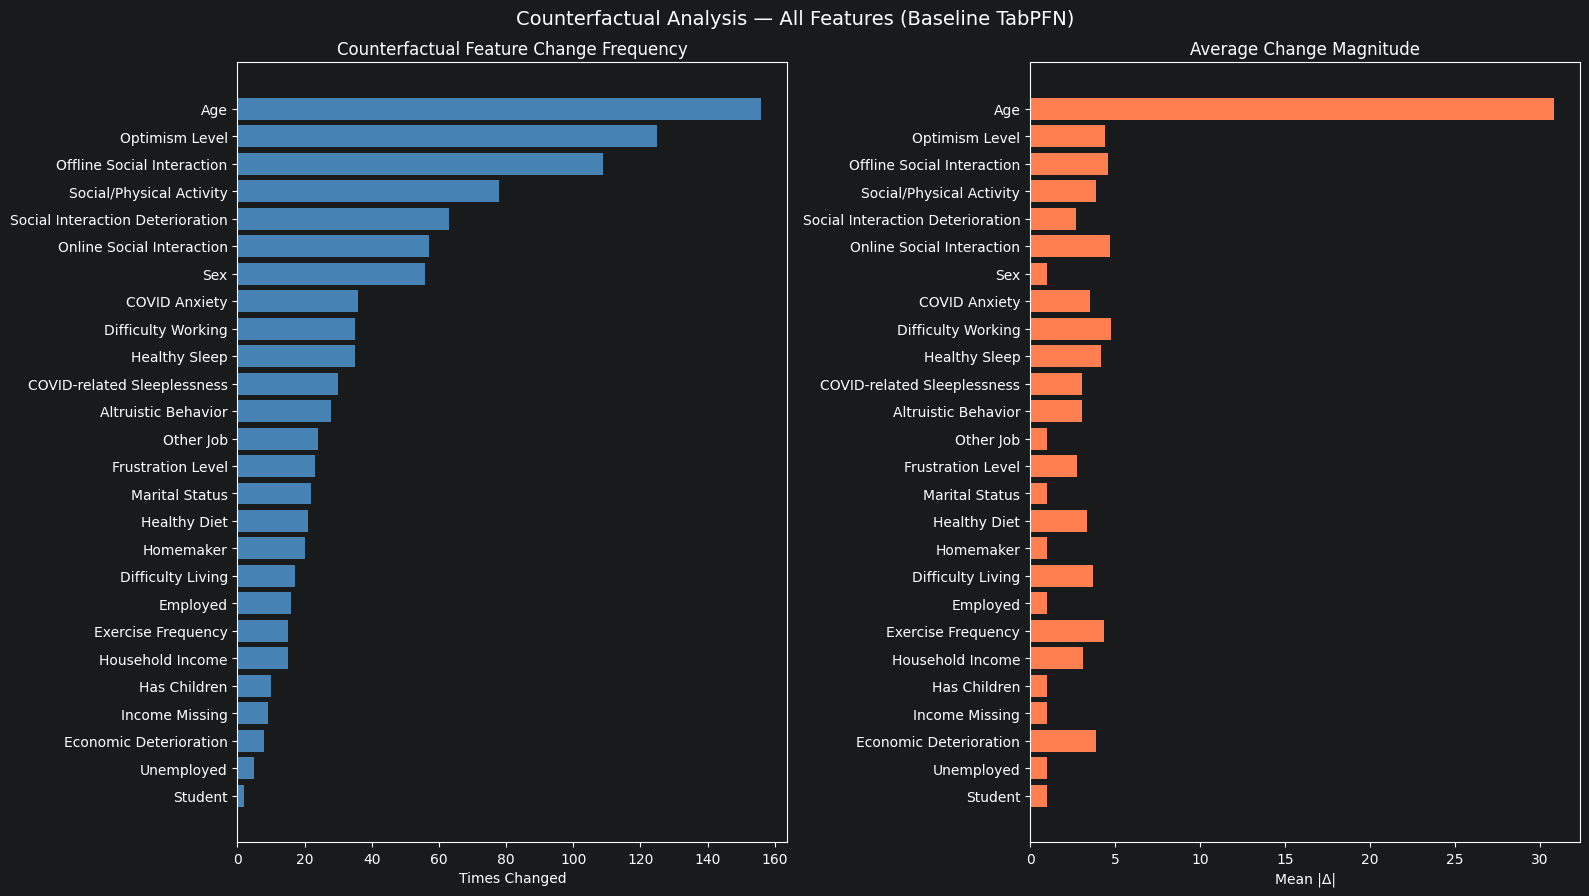

Saved: plots/counterfactuals/cf_feature_analysis.png


,Feature,Display Name,Change Count,Avg Magnitude,Dominant Direction
1,Age,Age,156,30.833333,increase
19,Optimism,Optimism Level,125,4.424000,increase
15,Interaction_Offline,Offline Social Interaction,109,4.559633,increase
11,Activity,Social/Physical Activity,78,3.858974,increase
23,Deterioration_Interact,Social Interaction Deterioration,63,2.682540,decrease
16,Interaction_Online,Online Social Interaction,57,4.684211,increase
0,Sex_Male,Sex,56,1.000000,decrease
20,Covid_Anxiety,COVID Anxiety,36,3.527778,increase
14,Healthy_Sleep,Healthy Sleep,35,4.171429,increase
25,Difficulty_Work,Difficulty Working,35,4.742857,increase


In [48]:
feature_change_counts = {feat: 0 for feat in features_UCLA}
feature_change_magnitudes = {feat: [] for feat in features_UCLA}
feature_change_directions = {feat: [] for feat in features_UCLA}

for result in cf_results:
    original = result["original_values"]
    for cf in result["counterfactuals"]:
        for feat in features_UCLA:
            if feat in cf and feat in original:
                diff = cf[feat] - original[feat]
                if abs(diff) > 0.01:
                    feature_change_counts[feat] += 1
                    feature_change_magnitudes[feat].append(abs(diff))
                    feature_change_directions[feat].append(
                        "increase" if diff > 0 else "decrease")

change_df = pd.DataFrame({
    "Feature": list(feature_change_counts.keys()),
    "Display Name": [get_display_name(f) for f in feature_change_counts.keys()],
    "Change Count": list(feature_change_counts.values()),
    "Avg Magnitude": [np.mean(v) if v else 0
                      for v in feature_change_magnitudes.values()],
    "Dominant Direction": [
        max(set(v), key=v.count) if v else "n/a"
        for v in feature_change_directions.values()
    ]
}).sort_values("Change Count", ascending=True)

# Show ALL features (including zero-count ones) for completeness
fig, axes = plt.subplots(1, 2, figsize=(16, max(8, n_features * 0.35)))

axes[0].barh(change_df["Display Name"],
             change_df["Change Count"], color="steelblue")
axes[0].set_title("Counterfactual Feature Change Frequency")
axes[0].set_xlabel("Times Changed")

axes[1].barh(change_df["Display Name"],
             change_df["Avg Magnitude"], color="coral")
axes[1].set_title("Average Change Magnitude")
axes[1].set_xlabel("Mean |Δ|")

plt.suptitle("Counterfactual Analysis — All Features (Baseline TabPFN)", fontsize=14)
plt.tight_layout()
plt.savefig("plots/counterfactuals/cf_feature_analysis.png", dpi=150, bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print("Saved: plots/counterfactuals/cf_feature_analysis.png")

# Summary table
display(change_df.sort_values("Change Count", ascending=False))


# 5. SHAP vs Counterfactual Comparison


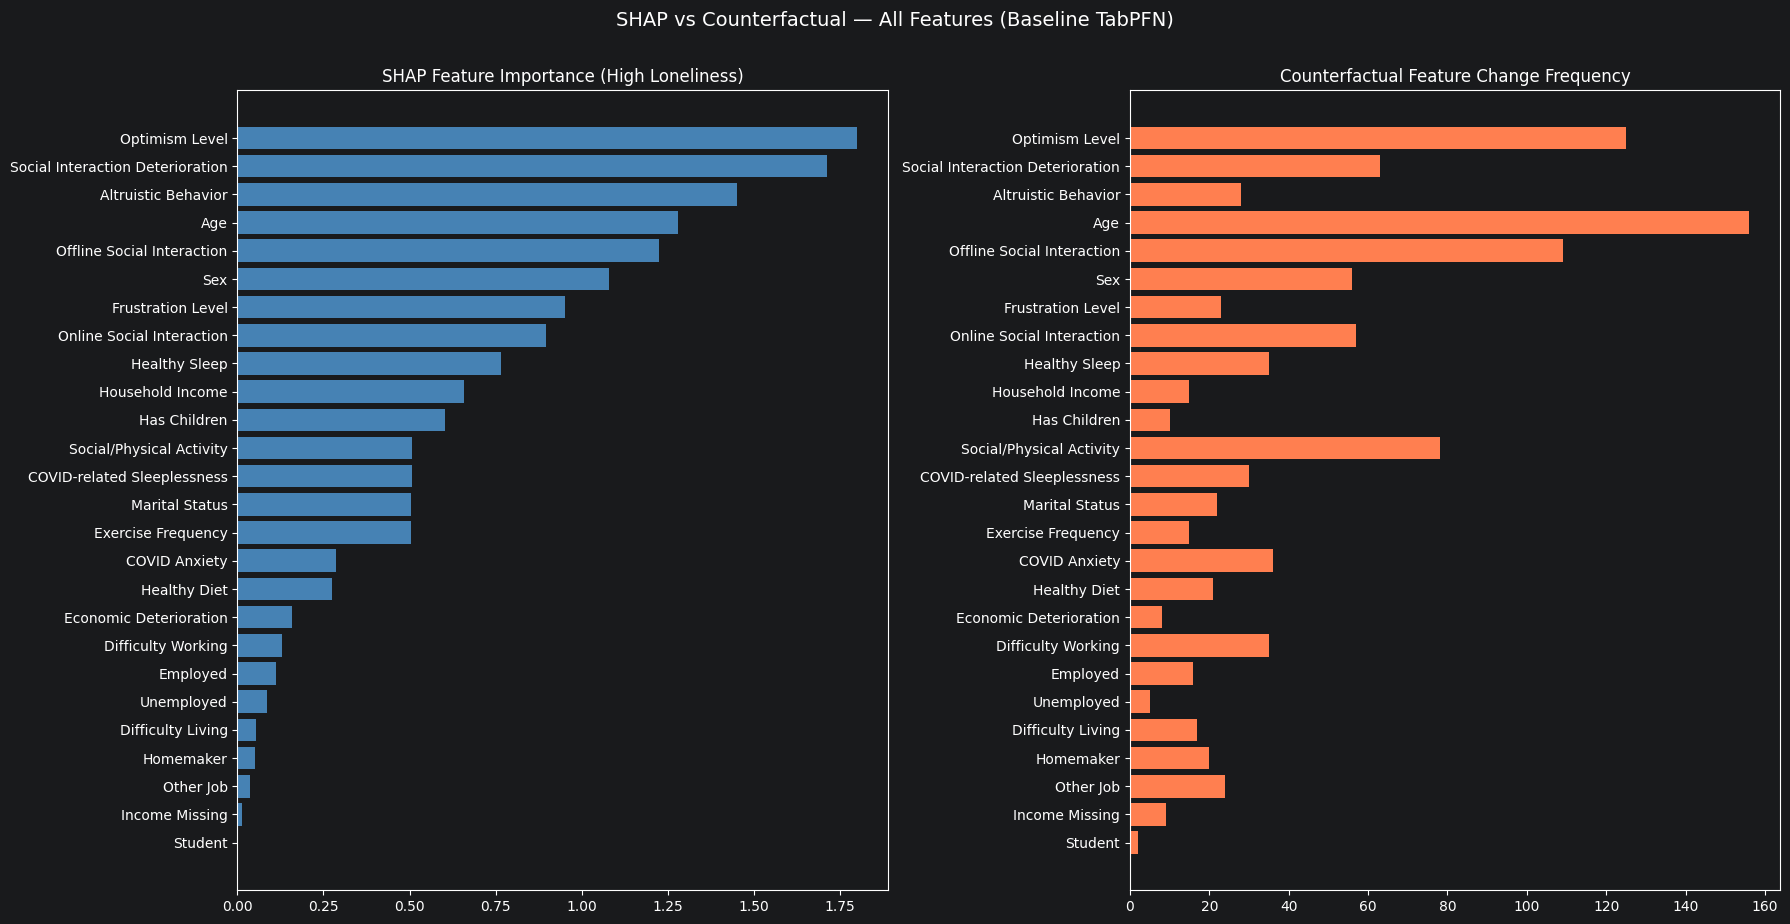

Saved: plots/shap_vs_counterfactual.png
Spearman rank correlation: ρ = 0.701, p = 0.0001
(High ρ means SHAP and counterfactuals agree on feature importance.)



,Feature,Display Name,SHAP Importance,Change Count
19,Optimism,Optimism Level,1.799131,125
23,Deterioration_Interact,Social Interaction Deterioration,1.714461,63
17,Altruistic,Altruistic Behavior,1.452954,28
1,Age,Age,1.279876,156
15,Interaction_Offline,Offline Social Interaction,1.226158,109
0,Sex_Male,Sex,1.079757,56
18,Frustration,Frustration Level,0.951110,23
16,Interaction_Online,Online Social Interaction,0.896929,57
14,Healthy_Sleep,Healthy Sleep,0.765512,35
4,Income,Household Income,0.659496,15


In [49]:
# SHAP importance (High Loneliness class)
class_idx = 1
shap_importance = np.abs(shap_values[class_idx]).mean(axis=0)
shap_df = pd.DataFrame({
    "Feature": features_list,
    "Display Name": get_display_names_list(features_list),
    "SHAP Importance": shap_importance
})

combined = shap_df.merge(
    change_df[["Feature", "Change Count"]], on="Feature", how="left"
).fillna(0)
combined = combined.sort_values("SHAP Importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, max(8, n_features * 0.35)))

axes[0].barh(combined["Display Name"], combined["SHAP Importance"],
             color="steelblue")
axes[0].set_title("SHAP Feature Importance (High Loneliness)")
axes[0].invert_yaxis()

axes[1].barh(combined["Display Name"], combined["Change Count"],
             color="coral")
axes[1].set_title("Counterfactual Feature Change Frequency")
axes[1].invert_yaxis()

plt.suptitle("SHAP vs Counterfactual — All Features (Baseline TabPFN)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("plots/shap_vs_counterfactual.png", dpi=150, bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print("Saved: plots/shap_vs_counterfactual.png")

rho, pval = spearmanr(combined["SHAP Importance"], combined["Change Count"])
print(f"Spearman rank correlation: ρ = {rho:.3f}, p = {pval:.4f}")
print("(High ρ means SHAP and counterfactuals agree on feature importance.)\n")

display(combined)


# 6. CFX Limitations: Excluding Demographic Features

In [50]:
# Define modifiable feature set: exclude demographics
IMMUTABLE_FEATURES = ["Age", "Sex_Male"]
features_to_vary = [f for f in features_UCLA if f not in IMMUTABLE_FEATURES]

print(f"Immutable (excluded): {IMMUTABLE_FEATURES}")
print(f"Modifiable features:  {len(features_to_vary)} of {len(features_UCLA)}")

# Constrain permitted ranges so DiCE cannot drift on the immutable features
permitted_range_limited = dict(permitted_range)
for feat in IMMUTABLE_FEATURES:
    permitted_range_limited[feat] = [
        float(X_train[feat].min()),
        float(X_train[feat].max()),
    ]


Immutable (excluded): ['Age', 'Sex_Male']
Modifiable features:  24 of 26


In [51]:
# Generate RESTRICTED CFs (demographics excluded) — same indices as the
# unrestricted run for direct comparison.
cf_results_limited = None
if (
    LOAD_SAVED_CF
    and os.path.exists("explainers/dice_results_limited.pkl")
):
    with open("explainers/dice_results_limited.pkl", "rb") as f:
        cf_results_limited = pickle.load(f)
    if _saved_indices_match(cf_results_limited, CF_SAMPLE_INDICES):
        print(f"Loaded {len(cf_results_limited)} saved restricted CFs.")
    else:
        print("Saved restricted CFs use different indices — regenerating.")
        cf_results_limited = None

if cf_results_limited is None:
    print(f"Generating RESTRICTED CFs for {len(CF_SAMPLE_INDICES)} samples "
          f"(features_to_vary excludes {IMMUTABLE_FEATURES})...")
    cf_results_limited, _summary_lim = _generate_batch_cfs(
        dice_exp, CF_SAMPLE_INDICES,
        total_cfs=N_CF_PER_SAMPLE,
        perm_range=permitted_range_limited,
        features_to_vary=features_to_vary,
        label="Demographics-Excluded",
    )
    _save_cf_artifacts(cf_results_limited,
                       "explainers/dice_results_limited.pkl",
                       "explainers/counterfactual_results_limited.pkl")

# Sanity check: unrestricted and restricted aligned 1-to-1
assert [r["sample_idx"] for r in cf_results] == \
       [r["sample_idx"] for r in cf_results_limited], \
    "Unrestricted and restricted CF runs must use the same sample indices."
print("Confirmed: unrestricted and restricted CFs are aligned by sample_idx.")


Loaded 60 saved restricted CFs.
Confirmed: unrestricted and restricted CFs are aligned by sample_idx.


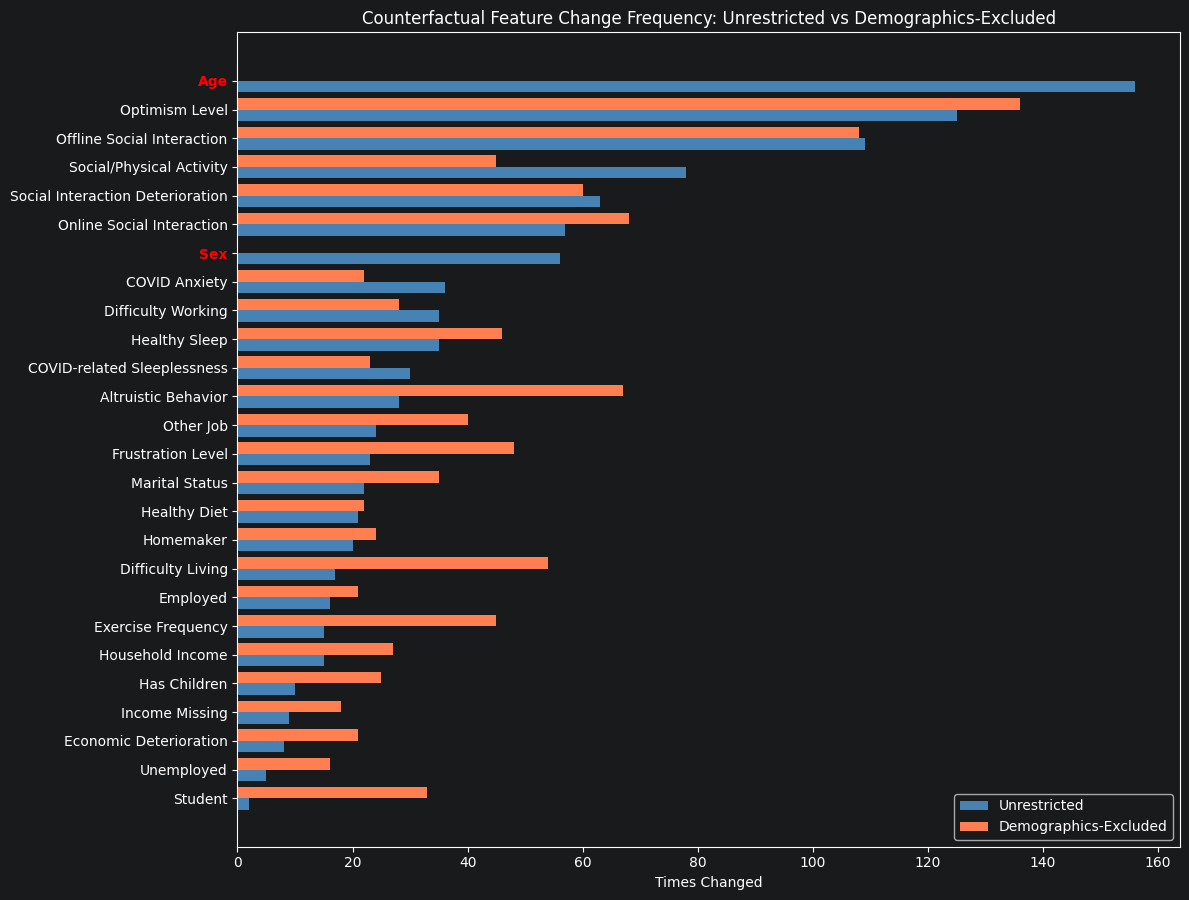

  ✓ Age: 0 changes in demographics-excluded run
  ✓ Sex_Male: 0 changes in demographics-excluded run

=== Feature-change counts ===


,Display Name,Unrestricted,Demographics-Excluded,Immutable
1,Age,156,0,True
19,Optimism Level,125,136,False
15,Offline Social Interaction,109,108,False
11,Social/Physical Activity,78,45,False
23,Social Interaction Deterioration,63,60,False
16,Online Social Interaction,57,68,False
0,Sex,56,0,True
20,COVID Anxiety,36,22,False
14,Healthy Sleep,35,46,False
25,Difficulty Working,35,28,False


In [52]:
# Compare feature-change frequencies: unrestricted vs limited
def compute_change_counts(cf_results, feature_list):
    counts = {f: 0 for f in feature_list}
    for r in cf_results:
        original = r["original_values"]
        for cf in r["counterfactuals"]:
            for feat in feature_list:
                if feat in cf and feat in original:
                    if abs(cf[feat] - original[feat]) > 0.01:
                        counts[feat] += 1
    return counts

counts_unrestricted = compute_change_counts(cf_results, features_UCLA)
counts_limited = compute_change_counts(cf_results_limited, features_UCLA)

limit_df = pd.DataFrame({
    "Feature": features_UCLA,
    "Display Name": [get_display_name(f) for f in features_UCLA],
    "Unrestricted": [counts_unrestricted[f] for f in features_UCLA],
    "Demographics-Excluded": [counts_limited[f] for f in features_UCLA],
    "Immutable": [f in IMMUTABLE_FEATURES for f in features_UCLA],
}).sort_values("Unrestricted", ascending=True)

fig, ax = plt.subplots(figsize=(12, max(8, n_features * 0.35)))
y_pos = np.arange(len(limit_df))
width = 0.4

ax.barh(y_pos - width/2, limit_df["Unrestricted"], height=width,
        label="Unrestricted", color="steelblue")
ax.barh(y_pos + width/2, limit_df["Demographics-Excluded"], height=width,
        label="Demographics-Excluded", color="coral")
ax.set_yticks(y_pos)
ax.set_yticklabels(limit_df["Display Name"])
ax.set_xlabel("Times Changed")
ax.set_title("Counterfactual Feature Change Frequency: Unrestricted vs Demographics-Excluded")
ax.legend()

# Highlight immutable features in red
for i, immutable in enumerate(limit_df["Immutable"].values):
    if immutable:
        ax.get_yticklabels()[i].set_color("red")
        ax.get_yticklabels()[i].set_fontweight("bold")

plt.tight_layout()
plt.savefig("plots/counterfactuals/cf_limitations_comparison.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

# Verify the constraint actually held: immutable features must show 0 changes
for feat in IMMUTABLE_FEATURES:
    n_changes = counts_limited[feat]
    status = '✓' if n_changes == 0 else '✗ VIOLATION'
    print(f'  {status} {feat}: {n_changes} changes in demographics-excluded run')

print("\n=== Feature-change counts ===")
display(limit_df.sort_values("Unrestricted", ascending=False)[
    ["Display Name", "Unrestricted", "Demographics-Excluded", "Immutable"]
])


# 7. Save & Verify Artifacts


In [53]:
os.makedirs("explainers", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

with open("explainers/cf_sample_indices.pkl", "wb") as f:
    pickle.dump(CF_SAMPLE_INDICES, f)

feature_info = {
    "features": features_UCLA,
    "target": target_UCLA,
    "cutoff": UCLA_cutoff,
    "class_names": class_names,
    "category_labels": CATEGORY_LABELS,
    "display_names": FEATURE_DISPLAY_NAMES,
    "likert_features": LIKERT_FEATURES,
    "immutable_features": IMMUTABLE_FEATURES,
    "cf_sample_indices": CF_SAMPLE_INDICES,
}
with open("explainers/feature_info.pkl", "wb") as f:
    pickle.dump(feature_info, f)

y_pred_all = model.predict(X_test)
y_prob_all = model.predict_proba(X_test)[:, 1]
with open("artifacts/test_predictions.pkl", "wb") as f:
    pickle.dump({"y_pred": y_pred_all, "y_prob": y_prob_all}, f)

X_train.to_csv("artifacts/X_train.csv", index=False)
X_test.to_csv("artifacts/X_test.csv", index=False)
y_train.to_csv("artifacts/y_train.csv", index=False)
y_test.to_csv("artifacts/y_test.csv", index=False)
X_explain.to_csv("artifacts/X_explain.csv", index=False)

# Encoded long-format dataset (with Phase) — used by the webapp EDA tab.
df_encoded.to_csv("artifacts/df_encoded.csv", index=False)

expected = [
    ("explainers/shap_values_test.pkl",          "SHAP values (all test samples)"),
    ("explainers/shap_expected_value.pkl",       "SHAP expected values"),
    ("models/surrogate.joblib",             "Surrogate model (TreeSHAP backbone)"),
    ("explainers/dice_results.pkl",              "Random CFs (list-of-dicts)"),
    ("explainers/counterfactual_results.pkl",    "Random CFs (dict-by-sample)"),
    ("explainers/dice_results_kdtree.pkl",       "KDTree CFs (list-of-dicts)"),
    ("explainers/counterfactual_results_kdtree.pkl", "KDTree CFs (dict-by-sample)"),
    ("explainers/dice_results_genetic.pkl",      "Genetic CFs (list-of-dicts)"),
    ("explainers/counterfactual_results_genetic.pkl", "Genetic CFs (dict-by-sample)"),
    ("explainers/dice_results_limited.pkl",      "Restricted CFs (list-of-dicts)"),
    ("explainers/counterfactual_results_limited.pkl", "Restricted CFs (dict-by-sample)"),
    ("explainers/cf_sample_indices.pkl",         "Shared CF sample indices"),
    ("explainers/feature_info.pkl",              "Feature metadata"),
    ("artifacts/test_predictions.pkl",           "Test-set predictions"),
    ("artifacts/X_train.csv",                    "Training features"),
    ("artifacts/X_test.csv",                     "Test features"),
    ("artifacts/y_train.csv",                    "Training targets"),
    ("artifacts/y_test.csv",                     "Test targets"),
    ("artifacts/X_explain.csv",                  "SHAP explained samples"),
    ("artifacts/df_encoded.csv",                 "Encoded long-format dataset (EDA tab)"),
]

print("=== Artifact manifest ===")
missing = []
for path, desc in expected:
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"  ✓ {path:55s}  {size_kb:>8.1f} KB  — {desc}")
    else:
        missing.append(path)
        print(f"  ✗ MISSING: {path:55s}  — {desc}")

if missing:
    print(f"\n{len(missing)} artifact(s) missing — run preceding cells first.")
else:
    print("\nAll artifacts present.")


=== Artifact manifest ===
  ✓ explainers/shap_values_test.pkl                             540.3 KB  — SHAP values (all test samples)
  ✓ explainers/shap_expected_value.pkl                            0.1 KB  — SHAP expected values
  ✓ models/surrogate.joblib                                    1431.2 KB  — Surrogate model (TreeSHAP backbone)
  ✓ explainers/dice_results.pkl                                  42.8 KB  — Random CFs (list-of-dicts)
  ✓ explainers/counterfactual_results.pkl                        35.0 KB  — Random CFs (dict-by-sample)
  ✓ explainers/dice_results_kdtree.pkl                           44.3 KB  — KDTree CFs (list-of-dicts)
  ✓ explainers/counterfactual_results_kdtree.pkl                 36.5 KB  — KDTree CFs (dict-by-sample)
  ✓ explainers/dice_results_genetic.pkl                          42.4 KB  — Genetic CFs (list-of-dicts)
  ✓ explainers/counterfactual_results_genetic.pkl                34.7 KB  — Genetic CFs (dict-by-sample)
  ✓ explainers/dice_results_limited